# EN.580.447 HW2 - Lillian Lam
## February 13, 2026

## Table of Contents
1. [Question 1: Pipeline impact on cell composition estimates](#question-1)
    - 1.1 [Cell type annotations](#cell-anno)
    - 1.2 [Stacked bar plot](#bar-1)
    - 1.3 [Summary](#summary-1)
2. [Question 2: Cell type compositions variation between samples](#question-2)
    - 2.1 [Sample cell type annotations](#cell-anno2)
    - 2.2 [Sample stacked bar plot](#bar-2)
    - 2.3 [Source of variation between samples](#summary-2)
3. [Question 3: Detecting rare populations](#question-3)
    - 3.1 [Pipeline](#pipeline)
    - 3.2 [Plots](#Plots)
    - 3.3 [Report](#Report)

---

**Acknowledgment:** Much of the code was taken from [Professor Patrick Cahan's scBasics notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/scBasics.ipynb).

In [2]:
#required install in google colab
!pip install scanpy
!pip install igraph

In [49]:
#required packages
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.sparse import csr_matrix
import seaborn as sns
import igraph as ig
import warnings
warnings.filterwarnings('ignore')

<a id='question-1'></a>
# 1. How does altering the pipeline impact cell composition estimates? If so, in what ways?

In [11]:
!wget https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_v3/pbmc_10k_v3_filtered_feature_bc_matrix.h5

--2026-02-14 00:48:36--  https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_v3/pbmc_10k_v3_filtered_feature_bc_matrix.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37491093 (36M) [binary/octet-stream]
Saving to: ‘pbmc_10k_v3_filtered_feature_bc_matrix.h5.1’

pbmc_10k_v3_filtere 100%[===================>]  35.75M   185MB/s    in 0.2s    

2026-02-14 00:48:37 (185 MB/s) - ‘pbmc_10k_v3_filtered_feature_bc_matrix.h5.1’ saved [37491093/37491093]



In [10]:
#sample 1
adata_1 = sc.read_10x_h5('pbmc_10k_v3_filtered_feature_bc_matrix.h5')
adata_1.var_names_make_unique()

## scRNA Sequencing Pipeline Function
I made the ```pipeline``` function to process the raw 10x Genomics data through quality control, normalization, clustering, and visualization. The function is designed to test how different parameter choices affect downstream results by allowing each step to be toggled on/off or modified independently.

### Pipeline Steps (things that can be altered are conditional)
1. Quality Control
    - Mitochondrial gene identification: Flags genes starting with "MT-" as mitochondrial
    - Ribosomal gene identification: Flags genes starting with "RPS" or "RPL" as ribosomal
    - QC metric calculation: Computes n_genes, total_counts, pct_counts_mt, pct_counts_ribo

    - Cell filtering (conditional):
      - Remove cells with high mitochondrial content (> threshold)
      - Remove cells with low gene counts (< min_genes)
      - Remove cells with high UMI counts (> max_counts) to eliminate doublets

    - Gene filtering: Removes genes detected in fewer than 10 cells

2. Normalization (conditional)
    - Library size normalization: Scales each cell to 10,000 total counts
    - Log transformation: Applies log1p transformation to stabilize variance

3. Highly Variable Gene Selection

    Identifies top 2000 genes with highest variance (heteroskedasticity) across cells. These genes are most informative for distinguishing different cell populations, while housekeeping genes that are expressed similarly across all cells contribute little discriminatory power.These genes will be used for downstream dimensionality reduction.

4. Dimensionality Reduction
    - PCA: Performs principal component analysis on highly variable genes
      - Many genes are correlated in their expression patterns, so there is redundancy in the data.
     - Allows us to capture the variance in the data, instead of the whole genome, making it computationally less exhausting

    - kNN graph (conditional):
      - If use_pcs=True: Uses first n_pcs principal components
      - If use_pcs=False: Uses full HVG expression matrix
      - creates an adjacency matrix by finding, for each cell, the k cells that are closest to it.
      - encodes the local structure of the data, which becomes the backbone of both UMAP and Leiden clustering.

5. Clustering and Visualization
    - UMAP: 2D visualization of cell relationships
    - Leiden clustering: Resolution: 0.5 for more finer clusers (to identify subtypes)

    

In [40]:
def pipeline(adata_raw, filter_mt=True, mt_threshold=20, filter_counts=True,
             max_counts=30000,filter_genes=True, min_genes=500, normalize=True,
             use_pcs=True, n_pcs=10, n_neighbors=20, leiden_resolution=0.5, silent=False, figure_size=(10,5)):

    #new copy each time
    adata = adata_raw.copy()

    # QUALITY CONTROL

    #mitochondrial genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    # ribosomal genes
    ribo_prefix = ('RPS', 'RPL')
    adata.var['ribo'] = adata.var_names.str.startswith(ribo_prefix)

    #calculate QC metrics to filter out mitocondrial data
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'], percent_top=None, log1p=False, inplace=True)

    #filter cells based on parameters
    if filter_mt:
        adata = adata[adata.obs['pct_counts_mt'] < mt_threshold, :].copy()
    if filter_genes:
        sc.pp.filter_cells(adata, min_genes=min_genes)
    if filter_counts:
        sc.pp.filter_cells(adata, max_counts=max_counts)

    sc.pp.filter_genes(adata, min_cells=10)
    adata.var_names_make_unique()

    #NORMALIZATION

    if normalize:
        #proportion of reads for a gene relative to total library size
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        #store log-normalized data in a new layer
        adata.layers['lognorm'] = adata.X.copy()

    #IDENTIFY HIGHLY VARIABLE GENES

    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='cell_ranger')

    #DIMENSIONAL REDUCTION & CLUSTERING

    sc.tl.pca(adata, mask_var='highly_variable')

    #kNN graph with or without pcs
    if use_pcs:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=0)
    else:
        #use the full expression matrix (highly variable genes only)
        adata_hvg = adata[:, adata.var['highly_variable']].copy()
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep='X', random_state=0)

    #UMAP and Leiden clustering
    sc.tl.umap(adata, random_state=0)
    sc.tl.leiden(adata, resolution=leiden_resolution, flavor='igraph', n_iterations=2, key_added='leiden_cluster')

    #marker gene dictionary from homework 1
    marker_genes = {
        'CD14 Monocyte': ['CD14', 'LYZ', 'S100A8', 'S100A9', 'CCR2'],
        'CD14 CD16 Monocyte': ['CD14', 'CD163', 'IL1B', 'FCGR3A'],
        'CD16 Monocyte': ['CX3CR1', 'CCR5', 'FCGR3A'],
        'Pan T cell': ['CD3D', 'CD3E', 'CD3G'],
        'CD4 T cell': ['CD4', 'GATA3'],
        'CD8 T cell': ['CD8A', 'CD8B', 'EOMES', 'KLRG1'],
        'B cell': ['CD19', 'CD79A', 'CD79B', 'MS4A1'],
        'NK cell': ['GNLY', 'NKG7'],
        'DC': ['FLT3', 'CD1C'],
        'pDC': ['IL3RA', 'CLEC4C'],
        'Platelets': ['TUBB1', 'PPBP', 'CAVIN2']}

    #I added this because sample 3 did not have some of the marker genes
    filtered_markers = {}
    for cell_type, genes in marker_genes.items():
        present_genes = [g for g in genes if g in adata.var_names]
        if present_genes:
            filtered_markers[cell_type] = present_genes

    if not silent:
      sc.pl.umap(adata, color=['leiden_cluster'], legend_loc='on data', size=10, frameon=False)
      sc.tl.dendrogram(adata, groupby='leiden_cluster')
      #plot the dotplot to see if marker genes are expressd
      #helps to identify what cell type is in the cluster
      sc.pl.dotplot(adata, filtered_markers, groupby='leiden_cluster', dendrogram=True, var_group_rotation=45, figsize=figure_size)
      #violin plot to see the distribution of total gene expression per cluster
      sc.pl.violin(adata, ['total_counts'], groupby='leiden_cluster', rotation=90)

    return adata

<a id='cell-anno'></a>
## 1.1 Cell type annotations for each altered pipeline

### Cell Type Annotation Rationale (Baseline)

CD8 T cells (Clusters 0, 7): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 1): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 9): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 8, 13): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 6): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 4, 5): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 11): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 10): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 2): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 3): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 12): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 14): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.

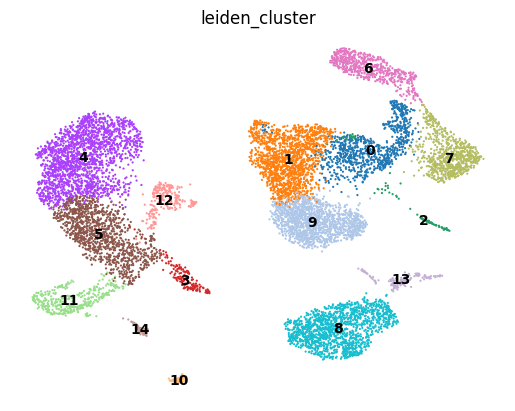

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


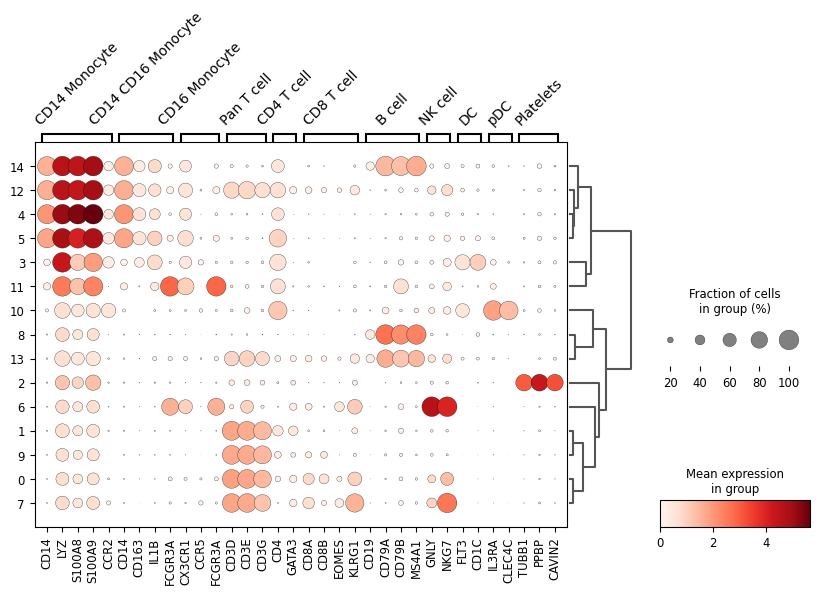

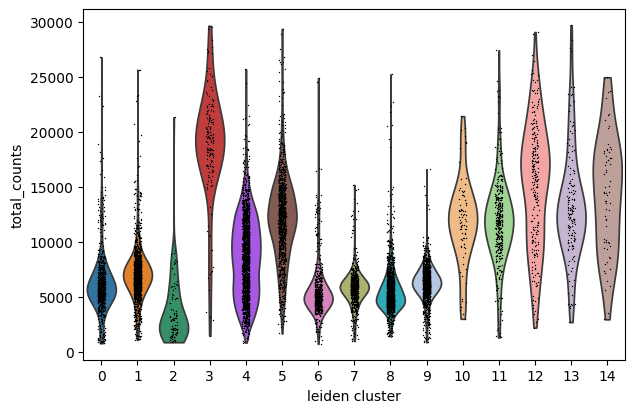

In [18]:
baseline = pipeline(adata_1)

### Cell Type Annotation Rationale (No MT filter)

CD8 T cells (Clusters 0, 10): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 7): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 1): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 5, 14): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 4): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 3, 8, 9): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 11): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 6): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 12): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 2): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 13): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 15): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.


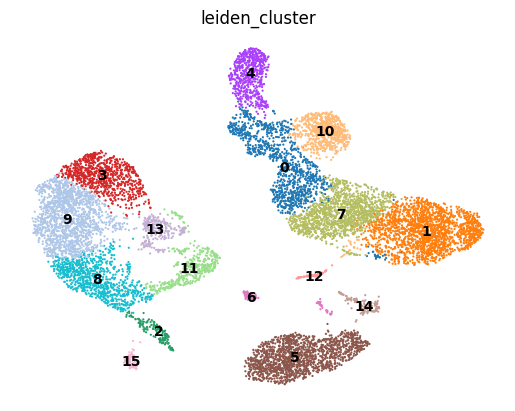

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


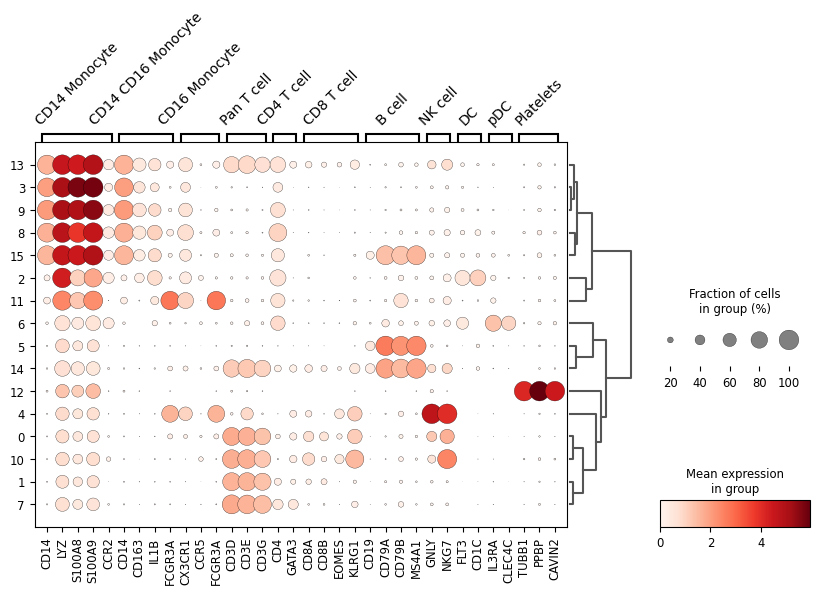

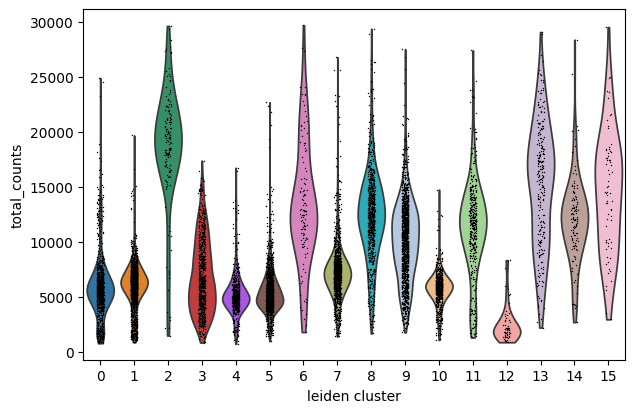

In [19]:
No_MT_filter = pipeline(adata_1, filter_mt=False)

### Cell Type Annotation Rationale (No total UMI counts filter)

CD8 T cells (Clusters 9, 12): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 1): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Clusters 0,7 ): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 5, 15): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 4): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 3,6): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 11): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 8): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 10): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 2): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 14): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 16): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.

doublet (Cluster 13): This cluster does not highly express any of the markers, but it has elivated UMI counts (~20,000 to ~80,000) confirming doublet status.

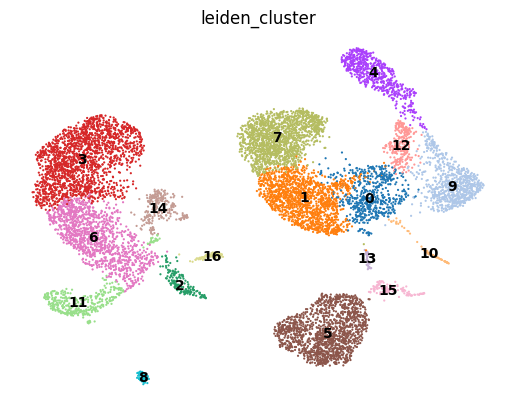

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


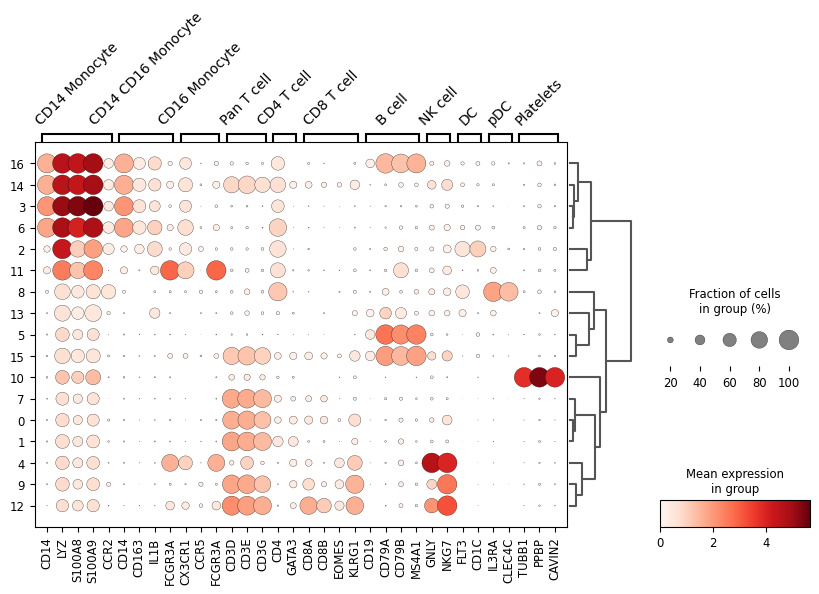

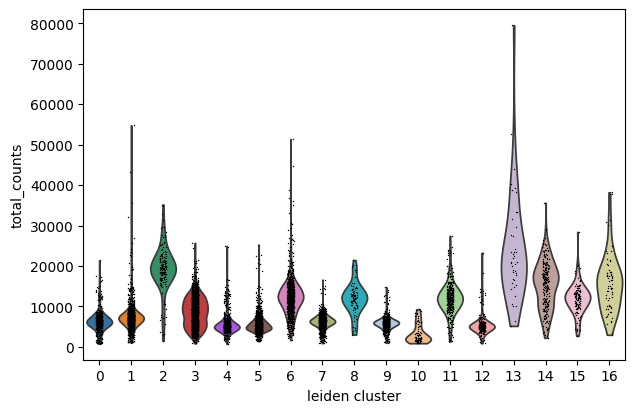

In [20]:
No_counts_filter = pipeline(adata_1, filter_counts=False)

### Cell Type Annotation Rationale (No normalization)

I felt that the expression levels for all of the genes were low.

CD8 T cells (Clusters 6): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)


Pan T cells (Clusters 7,8,9): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation. The CD4 levels were all low and matched cluster 6 (CD8), so I assume they were not CD4 T cells.They also didn't really express CD8 genes.

B cells (Clusters 4, 12): Highest expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20).

NK cells (Cluster 5): High GNLY and NKG7 expression without high T cell markers.

CD14 Monocytes (Clusters 2,3,10): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2). They were low on every other marker gene.

CD16 Monocytes (Cluster 11): High FCGR3A (CD16) expression with low CD14


Platelets (Cluster 0): Highest levels of TUBB1, PPBP, CAVIN2 and is low on every other marker gene.

Mono/DC doublet (Cluster 1): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

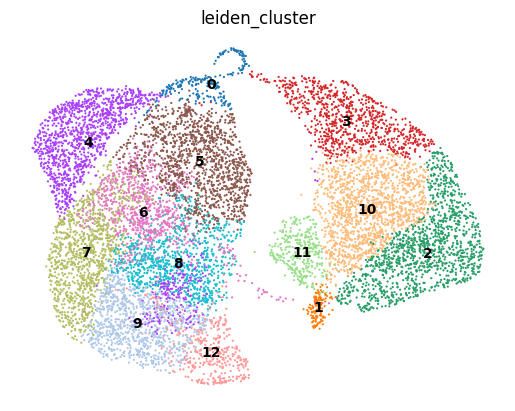

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


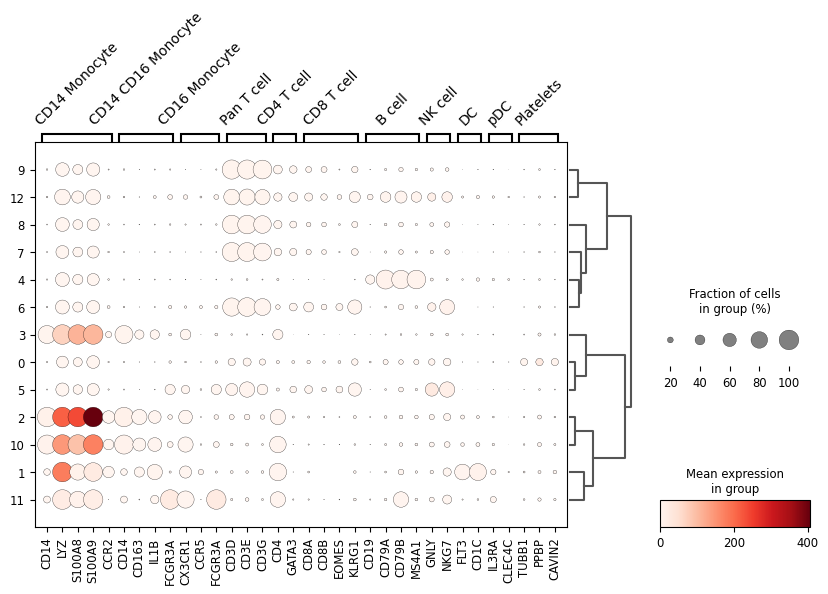

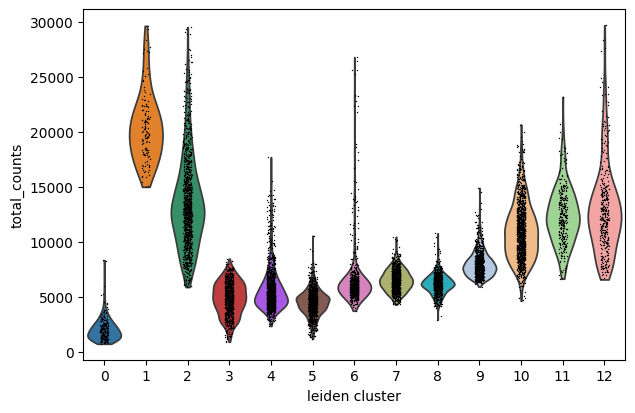

In [21]:
No_noralization_filter = pipeline(adata_1, normalize=False)

### Cell Type Annotation Rationale (No pcs for kNN graph)

Pan T cells (Cluster 0): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 3): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

CD14 Monocytes (Clusters 2): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 5): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 4): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 6): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 1): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

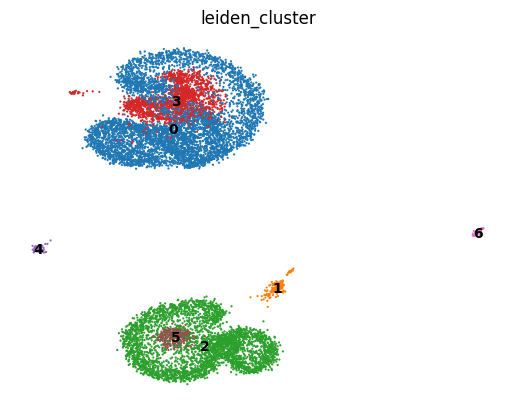

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


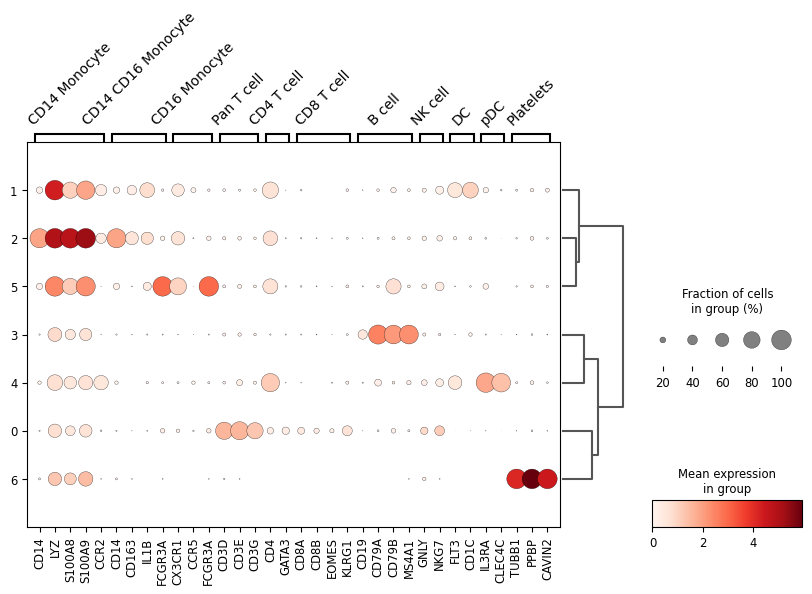

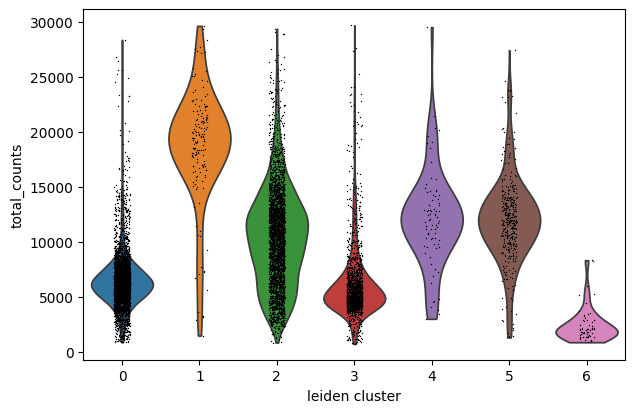

In [22]:
No_pc = pipeline(adata_1, use_pcs=False)

### Cell Type Annotation Rationale (PC=3 for kNN)

CD8 T cells (Clusters 10, 15): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1).

CD4 T cells (Clusters 0,1,2,3): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression. These cluster have more CD4 than the CD8 clusters.


B cells (Clusters 11, 12): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 9): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 6, 7, 8, 13): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 4): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 14): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 10): High in TUBB1, PPBP, CAVIN2.

B/T cells & Platelets (Cluster 5):  Co-expresses B cell markers (CD39A/B), T cell markers (CD3D/E/G), and platelet(TUBB1, PPBP, CAVIN2) markers. It has 2 humps in the violin plot, which might be 2 cell types. I think the clustering algorithm had trouble distinguishing the cell types since the PC are not capturing all the variance.

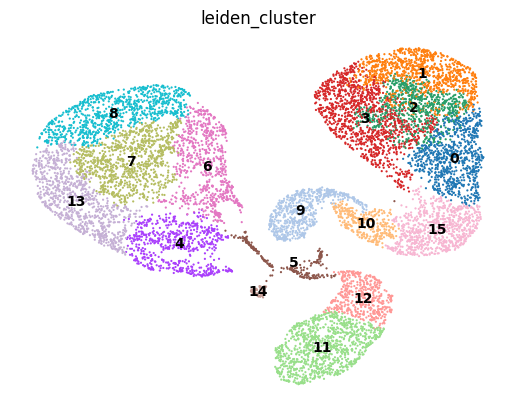

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


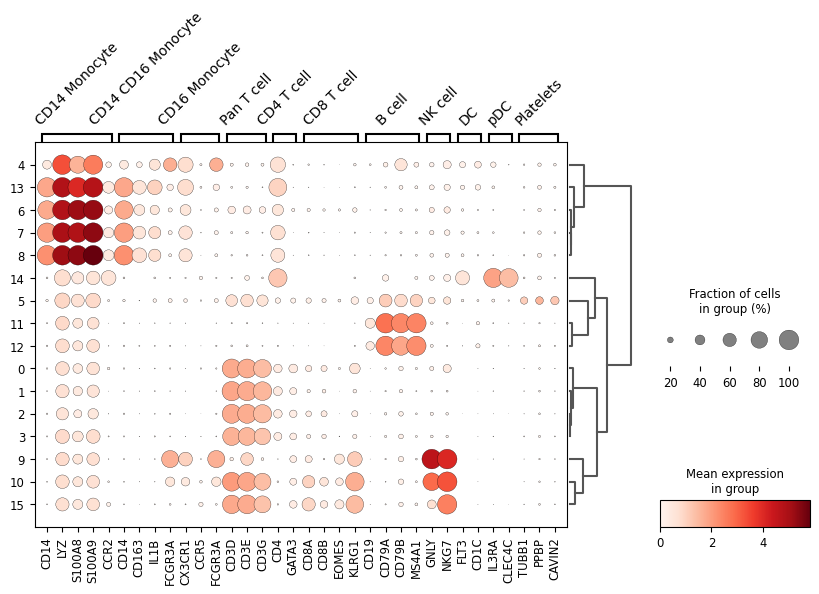

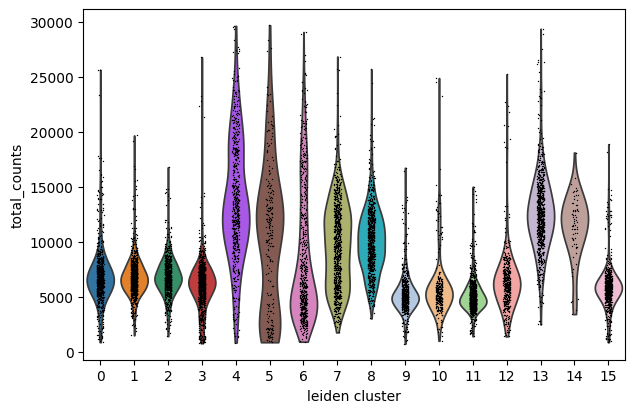

In [24]:
N_pc_3 = pipeline(adata_1, n_pcs=3)

### Cell Type Annotation Rationale (PC=50 for kNN)

CD8 T cells (Clusters 5,6,11): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 4,): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 8): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 9,14,16): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 3): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 2,7): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 12): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 10): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 13): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 1): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 15): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 17): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.

doublet (Cluster 18): This cluster does not highly express any of the markers, but it has elivated UMI counts (~20,000) confirming doublet status.

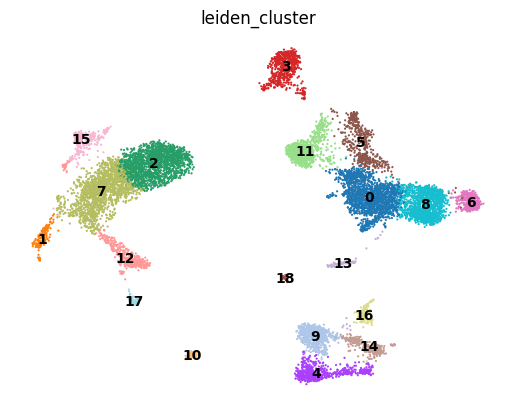

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


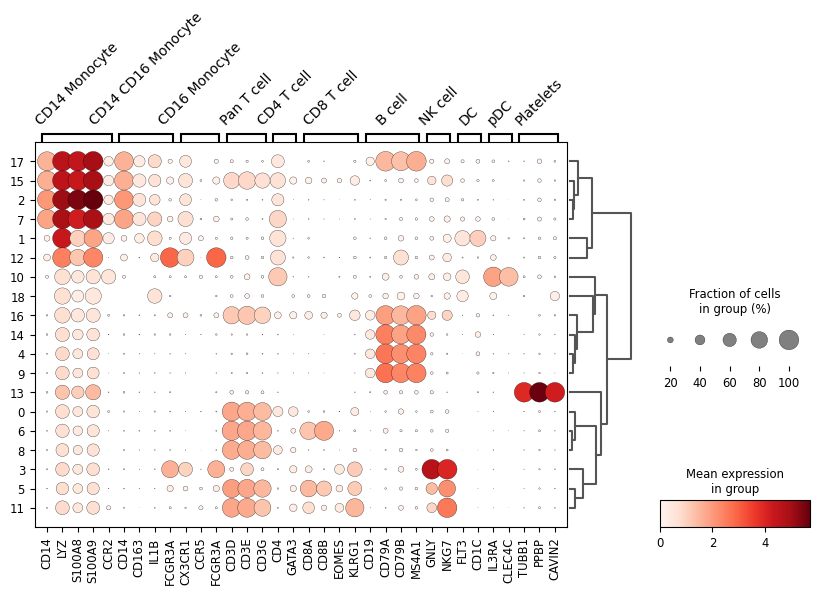

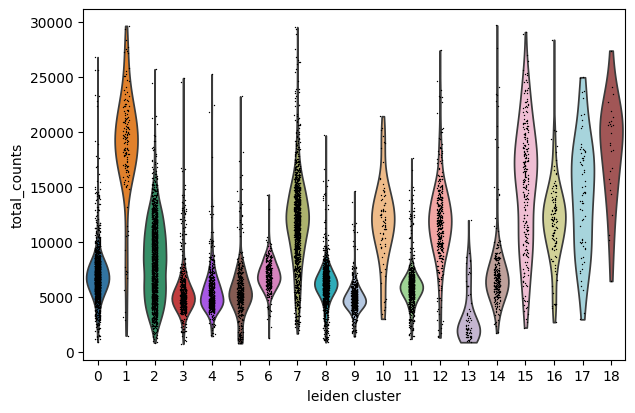

In [25]:
N_pc_50 = pipeline(adata_1, n_pcs=50)

### Cell Type Annotation Rationale (n_neighbors=3 for kNN)

This is over-fragmentation as we have 43 clusters, which is way too many, with many doublet-like clusters appearing.

CD8 T cells (Clusters 1, 4): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Clusters 5, 6, 35): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Clusters 0, 7, 33, 40): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 2, 19, 20, 21, 25, 34): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 18, 27): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 9, 14, 15, 16, 17, 36, 38): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Clusters 23, 28): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 22): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 13, 24): High in TUBB1, PPBP, CAVIN2.

Mixed, no doublet in annotation (Clusters 29, 12, 32, 39, 3, 41): I considered these clusters as mixed with 2 different cell types. They co-express markers from different cell types. I do not consider them doublets because the total counts is less than ~20,000.

Doublets (Clusters 8, 42, 10, 11, 26, 37, 30, 31): These cluster co-express markers from different cell types. These clusters have have either high varience in the violin plot where some of the counts reach ~30,000 totals counts or the mean of the cluster is around ~20,000 or higher.

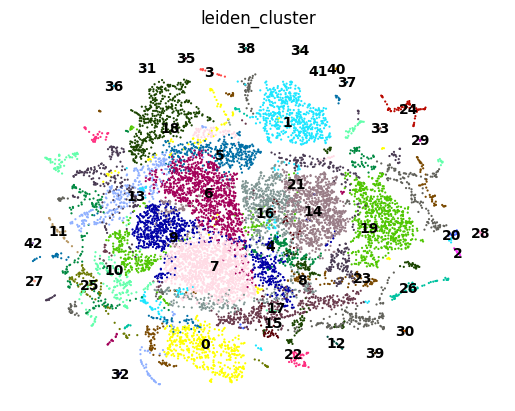

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


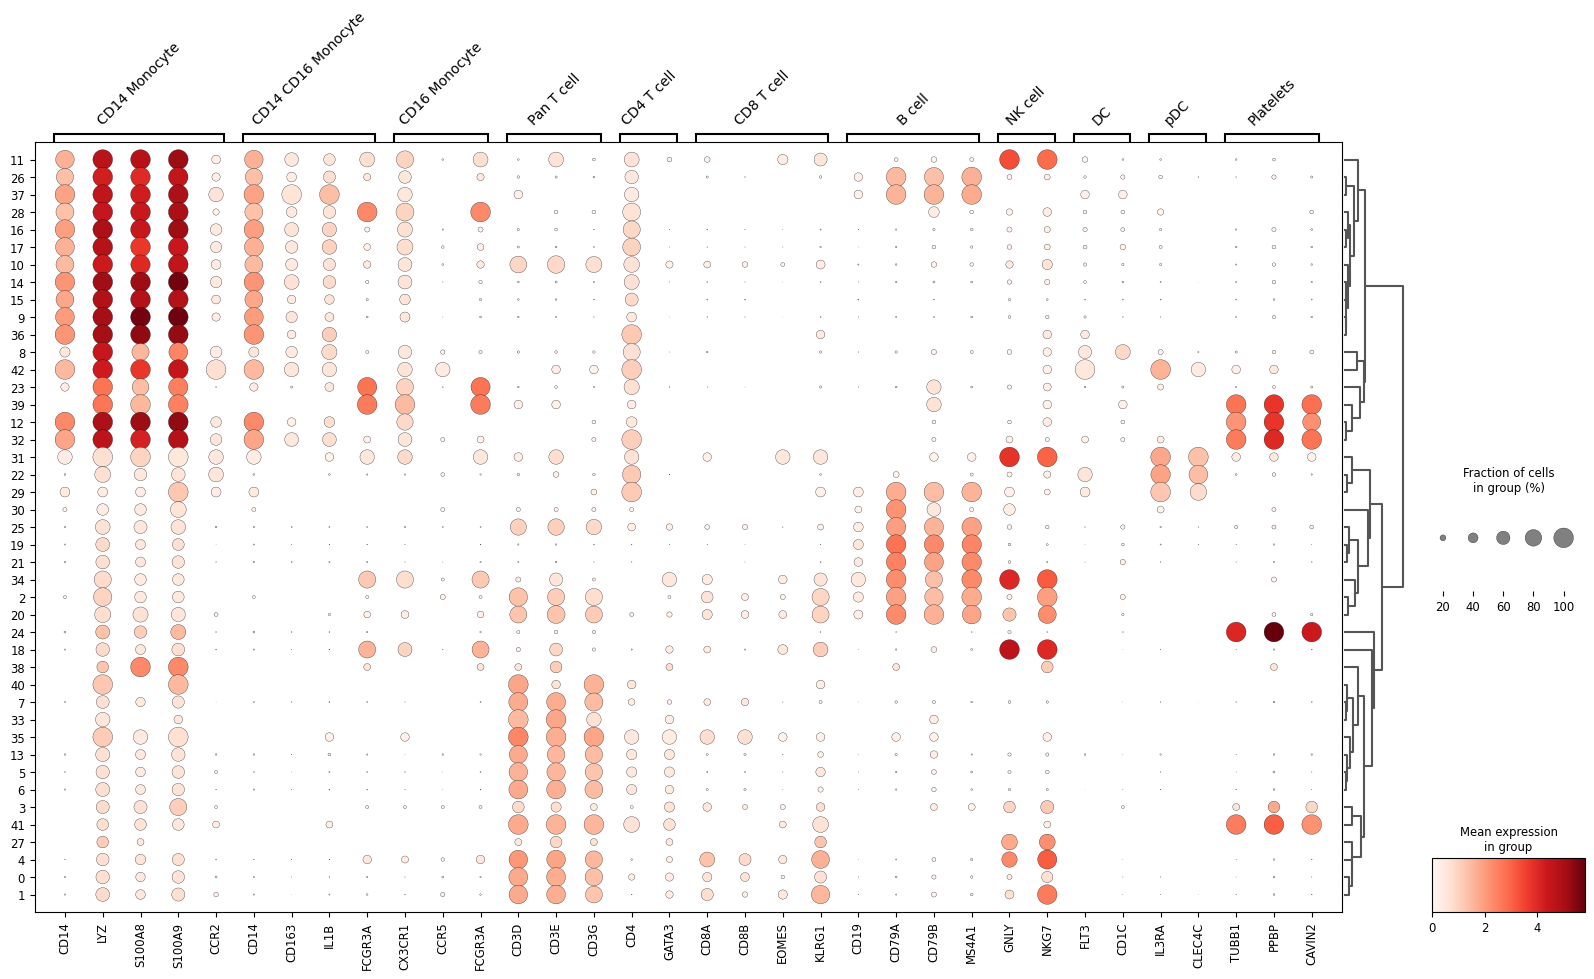

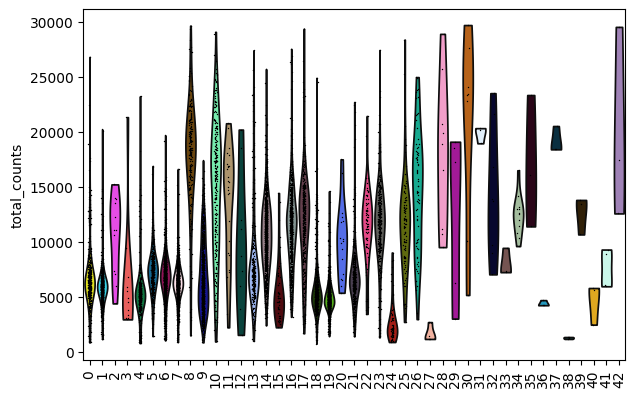

In [34]:
N_knn_3 = pipeline(adata_1, n_neighbors=3, figure_size=(20,10))

### Cell Type Annotation Rationale (n_neighbors=100 for kNN)

CD8 T cells (Clusters 0,11): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 1): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 9): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 5,6): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 4): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 3,8): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 12): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 10): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 7): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 2): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 13): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 14): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.

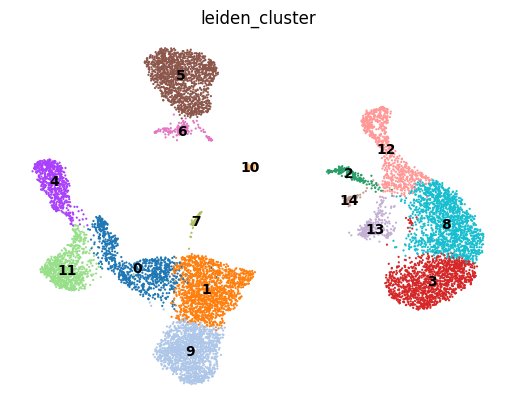

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


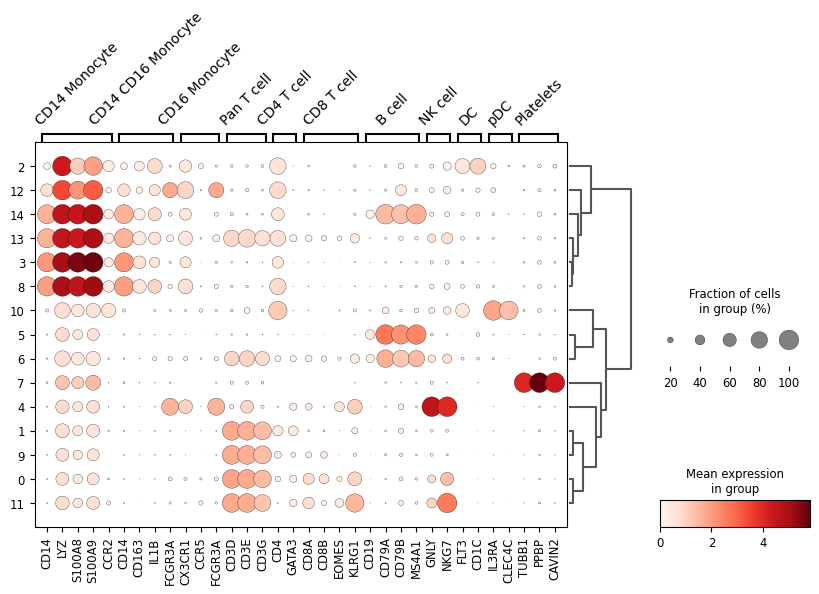

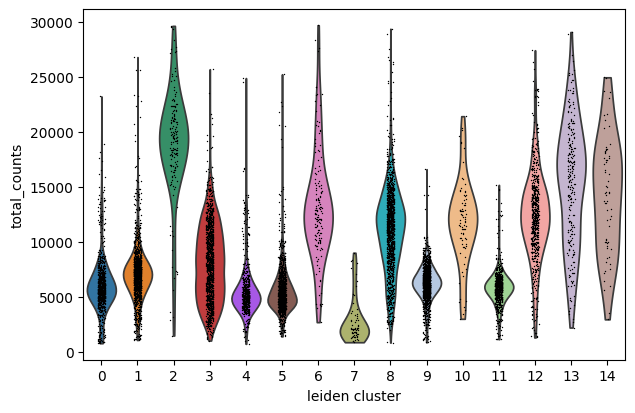

In [27]:
N_knn_100 = pipeline(adata_1, n_neighbors=100)

In [35]:
my_annotations = {
    'Baseline': {'0': 'CD8 T cell',
                 '1':'CD4 T cell',
                 '2': 'Platelets',
                 '3': 'Mono/DC doublet',
                 '4':'CD14 Monocyte',
                 '5': 'CD14 Monocyte',
                 '6': 'NK cell',
                 '7': 'CD8 T cell',
                 '8': 'B cell',
                 '9': 'Pan T cell',
                 '10': 'pDC',
                 '11': 'CD16 Monocyte',
                 '12':'T/Mono doublet',
                 '13':'B cell',
                 '14': 'B/Mono doublet'},
    'No_MT_filter': {'0': 'CD8 T cell',
                    '1':'Pan T cell',
                    '2': 'Mono/DC doublet',
                    '3': 'CD14 Monocyte',
                    '4':'Nk cell',
                    '5': 'B cell',
                    '6': 'pDC',
                    '7': 'CD4 T cell',
                    '8': 'CD14 Monocyte',
                    '9': 'CD14 Monocyte',
                    '10': 'CD8 T cell',
                    '11': 'CD16 Monocyte',
                    '12':'Platelets',
                    '13':'T/Mono doublet',
                    '14': 'B cell',
                    '15': 'B/Mono doublet'},
    'No_counts_filter':{'0': 'Pan T cell',
                        '1':'CD4 T cell',
                        '2': 'Mono/DC doublet',
                        '3': 'CD14 Monocyte',
                        '4':'Nk cell',
                        '5': 'B cell',
                        '6': 'CD14 Monocyte',
                        '7': 'Pan T cell',
                        '8': 'pDC',
                        '9': 'CD8 T cell',
                        '10': 'Platelets',
                        '11': 'CD16 Monocyte',
                        '12':'CD8 T cell',
                        '13':'doublet',
                        '14': 'T/Mono doublet',
                        '15': 'B cells',
                        '16': 'B/Mono doublet'},
    'No_normalization': {'0': 'Platelets',
                        '1':'Mono/DC doublet',
                        '2': 'CD14 Monocyte',
                        '3': 'CD14 Monocyte',
                        '4':'B cell',
                        '5': 'NK cell',
                        '6': 'CD8 T cell',
                        '7': 'Pan T cell',
                        '8': 'Pan T cell',
                        '9': 'Pan T cell',
                        '10': 'CD14 Monocyte',
                        '11': 'CD16 Monocyte',
                        '12':'B cell'},
    'No_pc': {'0': 'Pan T cell',
              '1':'Mono/DC doublet',
              '2': 'CD14 Monocyte',
              '3': 'B cell',
              '4':'pDC',
              '5': 'CD16 Monocyte',
              '6': 'Platelets'},

    'N_pc_3':{'0': 'CD4 T cell',
              '1':'CD4 T cell',
              '2': 'CD4 T cell',
              '3': 'CD4 T cell',
              '4':'CD16 Monocyte',
              '5': 'B/T cells & Platelets',
              '6': 'CD14 Monocyte',
              '7': 'CD14 Monocyte',
              '8': 'CD14 Monocyte',
              '9': 'NK cell',
              '10': 'CD8 T cell',
              '11': 'B cell',
              '12':'B cell',
              '13':'CD14 Monocyte',
              '14': 'pDC',
              '15': 'CD8 T cell'},
    'N_pc_50':{'0': 'CD4 T cell',
              '1':'Mono/DC doublet',
              '2': 'CD14 Monocyte',
              '3': 'NK cell',
              '4':'B cell',
              '5': 'CD8 T cell',
              '6': 'CD8 T cell',
              '7': 'CD14 Monocyte',
              '8': 'Pan T cell',
              '9': 'B cell',
              '10': 'pDC',
              '11': 'CD8 T cell',
              '12':'CD16 Monocyte',
              '13':'Platelets',
              '14': 'B cell',
              '15': 'T/Mono doublet',
              '16': 'B cell',
              '17': 'B/Mono doublet',
              '18': 'doublets'},
    'N_knn_3':{'0': 'Pan T cell',
              '1':'CD8 T cell',
              '2': 'B cell',
              '3': 'T/Platelet',
              '4':'CD8 T cell',
              '5': 'CD4 T cell',
              '6': 'CD4 T cell',
              '7': 'Pan T cell',
              '8': 'Mono/DC doublet',
              '9': 'CD14 Monocyte',
              '10': 'T/Mono doublet',
              '11': 'NK/Mono doublet',
              '12':'Mono/Platelet',
              '13':'Platelets',
              '14': 'CD14 Monocyte',
              '15': 'CD14 Monocyte',
              '16': 'CD14 Monocyte',
              '17': 'CD14 Monocyte',
              '18': 'NK cell',
              '19': 'B cell',
               '20': 'B cell',
               '21': 'B cell',
               '22':'pDC',
               '23':'CD16 Monocyte',
               '24': 'Platelets',
               '25': 'B cell',
               '26':'B/Mono doublet',
               '27': 'NK cell',
               '28':'CD16 Monocyte',
               '29': 'B/pDC',
               '30': 'doublet',
               '31': 'NK/DC doublet',
               '32':'Mono/Platelet',
               '33': 'Pan T cell',
               '34': 'B cell',
               '35': 'CD4 T cell',
               '36': 'CD14 Monocyte',
               '37': 'B/Mono doublet',
               '38': 'CD14 Monocyte',
               '39':'Mono/Platelets',
               '40': 'Pan T cell',
               '41': 'T/Platelet',
               '42':'Mono/DC doublet'},
    'N_knn_100':{'0': 'CD8 T cell',
              '1':'CD4 T cell',
              '2': 'Mono/DC doublet',
              '3': 'CD14 Monocyte',
              '4':'NK cell',
              '5': 'B cell',
              '6': 'B cell',
              '7': 'Platelets',
              '8': 'CD14 Monocyte',
              '9': 'Pan T cell',
              '10': 'pDC',
              '11': 'CD8 T cell',
              '12':'CD16 Monocyte',
              '13':'T/Mono doublet',
              '14': 'B/Mono doublet'}}

In [41]:
pipeline_adata_dict = {
    'Baseline': baseline,
    'No_MT_filter': No_MT_filter,
    'No_counts_filter': No_counts_filter,
    'No_normalization': No_noralization_filter,
    'No_pc': No_pc,
    'N_pc_3': N_pc_3,
    'N_pc_50': N_pc_50,
    'N_knn_3': N_knn_3,
    'N_knn_100': N_knn_100}

<a id='bar-1'></a>
## 1.2 Stacked Bar plot of each altered pipeline

In [77]:
def stacked_bar(annotations_dict, adata_dict, title=''):

    #add cluster identity to the cells
    for pipeline_name, annotation_dict in annotations_dict.items():
      adata = adata_dict[pipeline_name]
      #map cluster numbers to cell types using my annotations
      adata.obs['cell_type'] = adata.obs['leiden_cluster'].map(annotation_dict)

    #literature proportions (from the homework 1)
    literature_proportions = {'T cell': 70.0,
                              'B cell': 15.0,
                              'NK cell': 10.0,
                              'Monocyte': 5.0,
                              'Dendritic cell': 1.0,
                              'Platelets': 0.0}

    #dictionary to store proportions for each pipeline
    all_proportions = {}

    #calculate proportions for each pipeline
    for pipeline_name in annotations_dict.keys():
        adata = adata_dict[pipeline_name]

        #calculate proportions
        cell_counts = adata.obs['cell_type'].value_counts()
        total_cells = cell_counts.sum()
        cell_proportions = (cell_counts / total_cells * 100).round(2)

        #combining the subtypes into one cluster
        proportions_combined = {
            'T cell': cell_proportions.get('CD4 T cell', 0) + cell_proportions.get('CD8 T cell', 0) + cell_proportions.get('Pan T cell', 0),
            'B cell': cell_proportions.get('B cell', 0),
            'NK cell': cell_proportions.get('NK cell', 0),
            'Monocyte': cell_proportions.get('CD14 Monocyte', 0) + cell_proportions.get('CD16 Monocyte', 0),
            'Dendritic cell': cell_proportions.get('pDC', 0) + cell_proportions.get('DC', 0),
            'Platelets': cell_proportions.get('Platelets', 0)}

        all_proportions[pipeline_name] = proportions_combined

    #dataFrame with pipelines as rows
    proportion_df = pd.DataFrame(all_proportions).T

    #literature as a separate row for reference
    proportion_df.loc['Literature'] = literature_proportions

    fig, ax = plt.subplots(figsize=(12, 8))

    proportion_df.plot(kind='barh', stacked=True, ax=ax)

    plt.xlabel('Proportion (%)')
    plt.xlim(0, 100)
    plt.title(title)
    legend_labels = []
    for cat in proportion_df.columns:
        #start with cell type name
        label = f'{cat}\n'
        #values from each pipeline
        for pipeline in all_proportions.keys():
            val = all_proportions[pipeline][cat]
            label += f'     {pipeline}: {val:.1f}%\n'
         #add literature value
        label += f'     Literature: {literature_proportions[cat]:.1f}%'
        legend_labels.append(label)
    plt.legend(legend_labels, title='Cell Types Proportions',
               bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    return proportion_df

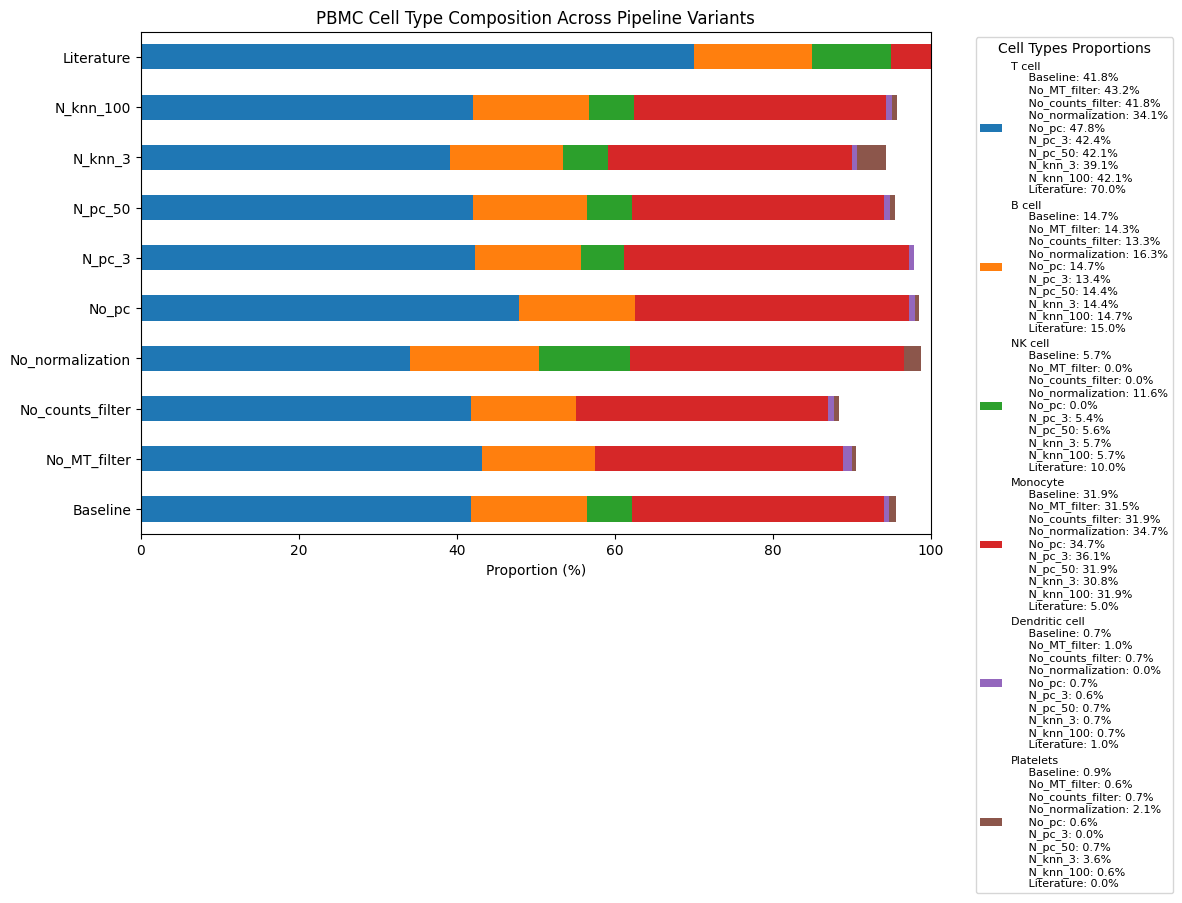

In [85]:
proportion_results =stacked_bar(annotations_dict=my_annotations, adata_dict=pipeline_adata_dict,title='PBMC Cell Type Composition Across Pipeline Variants')


In [86]:
proportion_results

,T cell,B cell,NK cell,Monocyte,Dendritic cell,Platelets
Baseline,41.76,14.71,5.67,31.90,0.74,0.89
No_MT_filter,43.18,14.28,0.00,31.49,1.04,0.55
No_counts_filter,41.80,13.27,0.00,31.92,0.74,0.70
No_normalization,34.12,16.29,11.55,34.69,0.00,2.14
No_pc,47.84,14.71,0.00,34.70,0.74,0.55
N_pc_3,42.35,13.37,5.43,36.14,0.64,0.00
N_pc_50,42.11,14.42,5.60,31.95,0.74,0.67
N_knn_3,39.10,14.38,5.70,30.83,0.67,3.61
N_knn_100,42.08,14.70,5.67,31.95,0.74,0.61
Literature,70.00,15.00,10.00,5.00,1.00,0.00


<a id='summary-1'></a>
## 1.3 Summary

Many of my interpretations came from reading:

Luecken, M. D., & Theis, F. J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial. Molecular systems biology, 15(6), e8746. https://doi.org/10.15252/msb.20188746

**Baseline Results:**
- 15 clusters identified
- Major cell types: CD8 T cells, CD4 T cells, B cells, NK cells, CD14 monocytes, CD16 monocytes, pDC, platelets
- 3 doublet clusters identified (Mono/DC, T/Mono, B/Mono)

##### 1. **No Mitochondrial Filtering** (filter_mt=False)

**Cell Composition Changes:**
- T cells: 41.8% -> 43.2% ($\uparrow$ 1.4%)
- B cells: 14.7% -> 14.3% ($\downarrow$ 0.4%)
- NK cells: 5.7% -> 0% ($\downarrow$ 5.7%)
- Monocytes: 31.9% -> 31.5% ($\downarrow$ 0.4%)
- Dendritic cells: 0.7% -> 1.0% ($\uparrow$ 0.3%)
- Platelets: 0.9% -> 0.6% ($\downarrow$ 0.3%)


I obtained 16 clusters (vs. 15 baseline), which implies that there is a slight increase in fragmentation. Lower quality cells retained, leading to noisier clustering. Some of the monocyte clusters split further due to heterogeneity in dying/stressed cells. High mitochondrial content percentage in a cell indicates cellular stress, apoptosis, or loss of cytoplasmic mRNA. This is because the cytoplasmic mRNA has leaked out, leaving only the mRNA from the more robust mitochondria behind. Without this filter, low-quality cells create artificial heterogeneity, fragmenting real populations and obscuring biological signal with technical noise.

### 2. **No Total Count Filtering** (filter_counts=False)

**Cell Composition Changes:**
- T cells: 41.8% -> 41.8% (stable)
- B cells: 14.7% -> 13.3% ($\downarrow$1.4%)
- NK cells: 5.7% -> 0% ($\downarrow$5.7%)
- Monocytes: 31.9% -> 31.9% (stable)
- Dendritic cells: 0.7% -> 0.7% (stable)
- Platelets: 0.9% -> 0.7% ($\downarrow$0.2%)

17 clusters were identified, which is over-clustering compared to baseline. There was an additional ambiguous doublet cluster (cluster 13) with very high UMI counts (20k-80k). Cells with >30,000 UMIs are usually doublets (two cells captured in one droplet). Without filtering, these doublets can co-express markers from multiple cell types, whcih can form distinct clusters due to their unique transcriptional profiles. Doublets can also artificially inflate certain populations, which can reduce the purity of real cell type populations through contamination. From the violin plots, we can see that the distribution of the clusters are much different from the baseline, which the total counts having many points skewed to 60,000 to 80,000, which is much larger than the normal population of around 10,000 total counts.

### 3. **No Normalization** (normalize=False)

**Cell Composition Changes:**
- T cells: 41.8% -> 34.1% ($\downarrow$7.7%)
- B cells: 14.7% -> 16.3% ($\uparrow$1.6%)
- NK cells: 5.7% -> 11.6% ($\uparrow$5.9%)
- Monocytes: 31.9% -> 34.7% ($\uparrow$2.8%)
- Dendritic cells: 0.7% -> 0.0% ($\downarrow$0.7%)
- Platelets: 0.9% -> 2.1% ($\uparrow$1.2%)

Only 13 clusters identified, which is under-clustering compared to the baseline. Marker gene expression appears globally suppressed, as there was a loss of CD4 T cell resolution. A lot of the CD4 and CD8 felt merged with Pan T cells, but that might just be my annotation mistake. The UMAP shows less structured organization. We know that without normalization library size bias dominates, which means that cells with more total UMIs drive the clustering, not biological variation. This is shown as the differences in cell type are obscured by technical variation in capture efficiency. Since raw counts span orders of magnitude, the distance metrics are dominated by high-abundance genes and the distribution of the genes is skewed (rather than appearing like a normalize distribution after log transforming). The large T cell increase and monocyte decrease likely reflects technical library size differences rather than true biology.

### 4. **No PC Dimensionality Reduction** (use_pcs=False)

**Cell Composition Changes:**
- T cells: 41.8% -> 47.8% ($\uparrow$6.0%)
- B cells: 14.7% -> 14.7% (stable)
- NK cells: 5.7% -> 0.0% ($\downarrow$5.7%)
- Monocytes: 31.9% -> 34.7% ($\uparrow$2.8%)
- Dendritic cells: 0.7% -> 0.7% (stable)
- Platelets: 0.9% -> 0.6% ($\downarrow$0.3%)

We see that there are only 7 clusters, so there is severe under-clustering compared to the baseline. The is a complete loss of NK cell resolution as it merged with other populations. There was a loss of T cell subtype resolution (no CD4/CD8 distinction), as I found it difficult to annotate subpopulations. The UMAP is less granular than the baseline. We know that scRNA-seq data is sparse and noisy. A gene expression matrix has thousands of dimensions, but most of these dimensions contain mostly zeros (dropouts) or technical noise. If we calculate distances directly on the full gene matrix, the noise from thousands of uninformative genes can overwhelm the signal from the biologically relevant genes, and the true variance structure becomes diluted. This prevents kNN from effectively identify similar cells due to the noise, which can lead to poor clustering.

### 5. **Extreme Low PCs** (n_pcs=3)

**Cell Composition Changes:**
- T cells: 41.8% -> 42.4% ($\uparrow$0.6%)
- B cells: 14.7% -> 13.4% ($\downarrow$1.3%)
- NK cells: 5.7% -> 5.4% ($\downarrow$0.3%)
- Monocytes: 31.9% -> 36.1% ($\uparrow$4.2%)
- Dendritic cells: 0.7% -> 0.6% ($\downarrow$0.6%)
- Platelets: 0.9% -> 0.0% ($\downarrow$0.9%)

There were 16 clusters identified, but there was poor separation in UMAP with many overlapping populations. Cluster 5 was ambiguous "B/T cells & Platelets" with a bimodal distribution in cluster 5 (two humps in violin plot), indicating a mixed population. There were multiple CD4 T cell clusters (0,1,2,3) that should be merged. The issue is that only 3 PCs captures insufficient variance, so we have information loss. The means that complex cell type differences cannot be represented in 3D, which forces merging of distinct populations overlap in low-dimensional space. Using only 3 PCs prevents us from distinguishing subtle but real differences, like CD4 subtypes. The mixed B/T/Platelet cluster demonstrates that with insufficient dimensions, the algorithm cannot properly separate cell types, creating biologically impossible clusters.

### 6. **Extreme High PCs** (n_pcs=50)

**Cell Composition Changes:**
- T cells: 41.8% -> 42.1% ($\uparrow$0.3%)
- B cells: 14.7% -> 14.4% ($\downarrow$0.3%)
- NK cells: 5.7% -> 5.6% ($\downarrow$0.1%)
- Monocytes: 31.9% -> 31.9% (stable)
- Dendritic cells: 0.7% -> 0.7% (stable)
- Platelets: 0.9% -> 0.7% ($\downarrow$0.2%)

There are 19 clusters, which is over-clustering compared to the baseline. There are multiple B cell clusters (4, 9, 14, 16) and CD8 T cell clusters (5, 6, 11), which are likely over-fragmentation. There is a more fragmented UMAP structure.
Much like using the highly variable genes, using 50 PCs reintroduces noise. Much of the late PCs capture noise. Beyond ~10-20 PCs (the elbow in the scree plot), components increasingly represent technical variation. Collecting this noise can lead to subtle technical differences that split real populations. The optimal PC number balances capturing biological variance (early PCs) while excluding noise (late PCs). For this dataset, 10 PCs appears optimal, which is what I used in the baseline.

### 7. **Extreme Low Neighbors** (n_neighbors=3)

**Cell Composition Changes:**
- T cells: 41.8% -> 39.1% ($\downarrow$2.7%)
- B cells: 14.7% -> 14.4% ($\downarrow$0.3%)
- NK cells: 5.7% -> 5.7% (stable)
- Monocytes: 31.9% -> 30.8% ($\downarrow$1.1%)
- Dendritic cells: 0.7% -> 0.7% (stable)
- Platelets: 0.9% -> 3.6% ($\uparrow$2.7%)

There were 43 clusters, which is severe over-fragmentation from the baseline.There were many small clusters representing technical noise or transitional states and multiple biologically similar clusters (e.g., 6 B cell clusters, 7 CD14 monocyte clusters). There were many ambiguous/mixed clusters without clear identity, and the UMAP shows highly fragmented, granular structure. With only 3 neighbors, the kNN graph becomes too local, which causes hyper-sensitivity. This means that every small difference creates a new cluster, and the model cannot integrate information across similar cells due to the noise being amplified in the clustering. This creates non-generalized clusters that only connects to cell very close to it. The kNN graph should balance local and global structure instead of having local structure dominate.

---

### 8. **Extreme High Neighbors** (n_neighbors=100)

**Cell Composition Changes:**
- T cells: 41.8% -> 42.1% ($\uparrow$0.3%)
- B cells: 14.7% -> 14.7% (stable)
- NK cells: 5.7% -> 5.7% (stable)
- Monocytes: 31.9% -> 31.9% (stable)
- Dendritic cells: 0.7% -> 0.7% (stable)
- Platelets: 0.9% -> 0.6% ($\downarrow$0.3%)

With 100 neighbors, we have 15 clusters (same as baseline), and very similar composition to baseline. There is a slightly smoother UMAP structure with similar doublet clsuters. High neighbor count is relatively well-tolerated because global structure preserved, so major populations still distinguish themselves. There is more noise smoothing because averaging over more neighbors reduces random variation. The issue is that we might lose fine-grained subpopulations, like some of the platelets, but major types remain. Interestingly, n_neighbors=100 performed better than n_neighbors=3, suggesting that over-smoothing is less problematic than over-fragmentation for this dataset.

---
Part 1 of the HW shows that parameter choices matter significantly. However, the effects are predictable. We definately need to do quality control, normalization, and PCA. QC directly impacts which cells are analyzed, and resolution parameters (PCs, neighbors) control granularity but are more forgiving than normalization. I still believe that the baseline pipeline with standard parameters (MT filter, count filter, normalization, 10 PCs, 20 neighbors) produced the most biologically interpretable and literature-consistent results, validating current best practices in the field.

<a id='question-2'></a>
# 2. To what extent do cell type compositions as estimated by scRNA-seq vary between samples?

<a id='cell-anno2'></a>
## 2.1 Cell Annotations of each sample

In [62]:
#sample 2
!wget https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_PBMC_3p_HT_nextgem_Chromium_X/20k_PBMC_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5

--2026-02-13 21:41:38--  https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_PBMC_3p_HT_nextgem_Chromium_X/20k_PBMC_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79198484 (76M) [binary/octet-stream]
Saving to: ‘20k_PBMC_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5’

20k_PBMC_3p_HT_next 100%[===================>]  75.53M  20.8MB/s    in 4.6s    

2026-02-13 21:41:44 (16.3 MB/s) - ‘20k_PBMC_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5’ saved [79198484/79198484]



In [64]:
#loading the new datasets
adata_2 = sc.read_10x_h5('20k_PBMC_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5')
adata_2.var_names_make_unique()
#Note: sample was downloaded from canvas and uploaded to the Google Colab Notebook
#will not run unless you upload the file
adata_3 = sc.read_10x_h5('Sample_3.h5')
adata_3.var_names_make_unique()

### Cell Type Annotation Rationale (Sample 1)

CD8 T cells (Clusters 0, 7): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 1): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 9): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 8, 13): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 6): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 4, 5): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 11): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 10): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 2): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 3): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~20,000) consistent with doublet identity.

T/Mono doublet (Cluster 12): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~20,000) confirm doublet status.

B/Mono doublet (Cluster 14): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated UMI counts (~20,000) confirm doublet status.

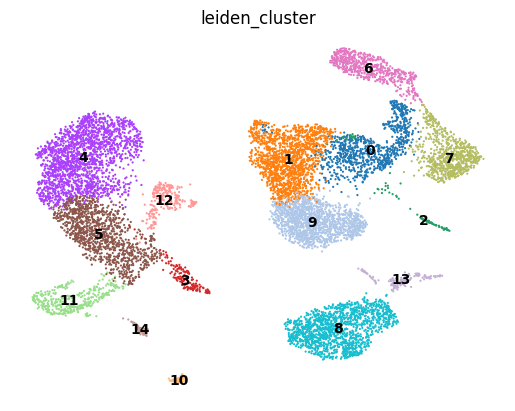

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


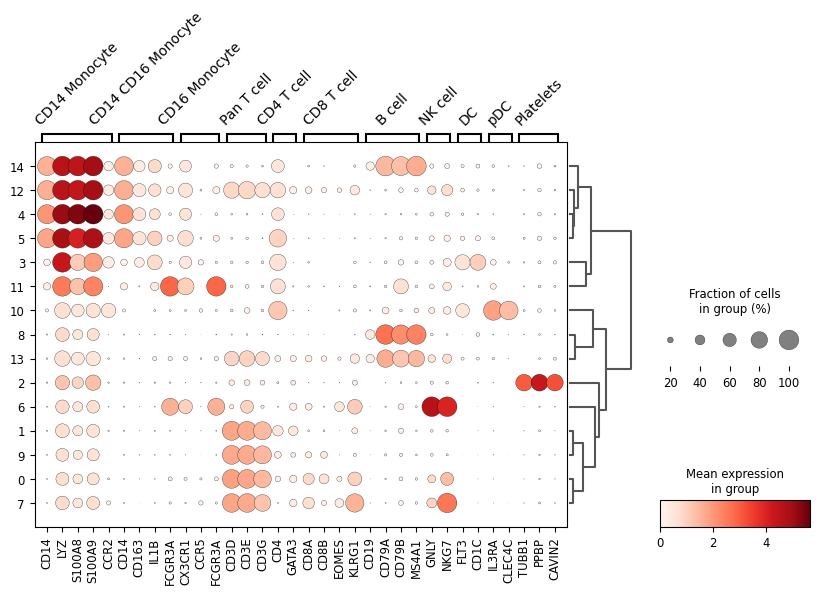

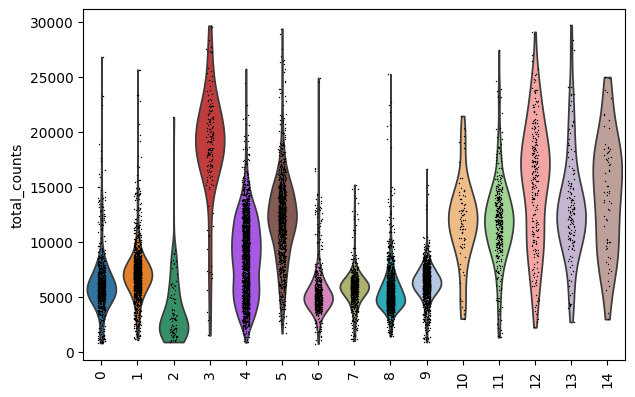

In [12]:
#following the original pipline parameters
sample_1 = pipeline(adata_1)

### Cell Type Annotation Rationale (Sample 2)

CD8 T cells (Clusters 5,9): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Cluster 7): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression

Pan T cells (Cluster 6): High expression of pan-T cell markers (CD3D, CD3E, CD3G) but without clear CD4 or CD8 differentiation

B cells (Clusters 10, 13): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 12): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Clusters 0,1): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 4): High FCGR3A (CD16) expression with low CD14

Plasmacytoid Dendritic Cells/pDC (Cluster 11): Highest expression of IL3RA (CD123) and CLEC4C

Platelets (Cluster 14): High in TUBB1, PPBP, CAVIN2.

Mono/DC doublet (Cluster 2): Expresses both monocyte markers and DC markers (FLT3, CD1C); likely monocyte-derived DC doublets. Shows elevated UMI counts (~18,000) consistent with doublet identity. The total count is higher than the other clusters.

T/Mono doublet (Cluster 8): Co-expresses T cell markers (CD3D/E/G) and CD14 monocyte markers; positioned between T cell and monocyte clusters in UMAP. Elevated UMI counts (~15,000) confirm doublet status.

B/Mono doublet (Cluster 3): Co-expresses B cell markers (CD39A/B) and CD14 monocyte markers; Elevated total UMI counts (~15,000) confirm doublet status.

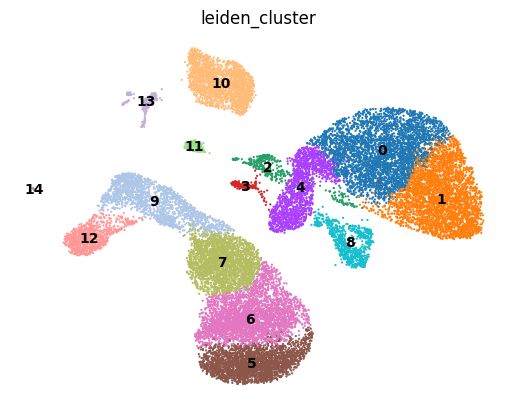

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


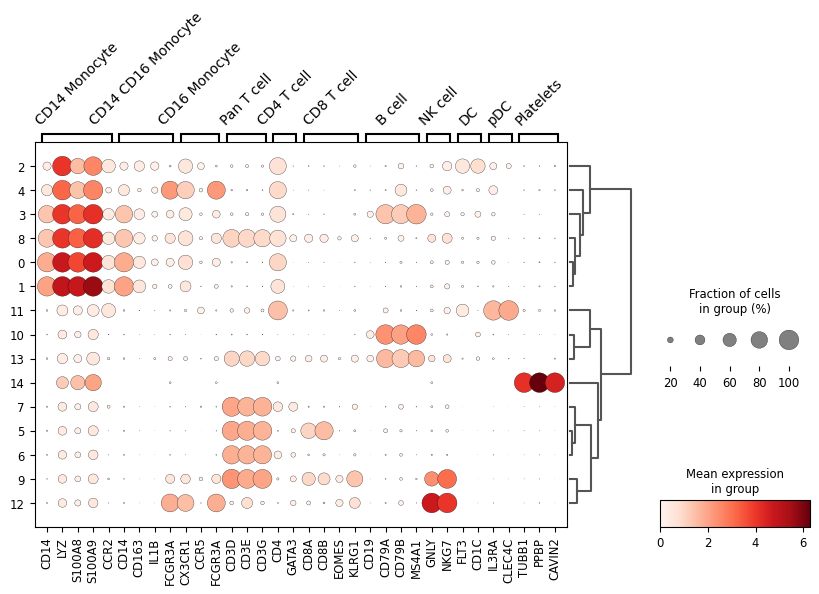

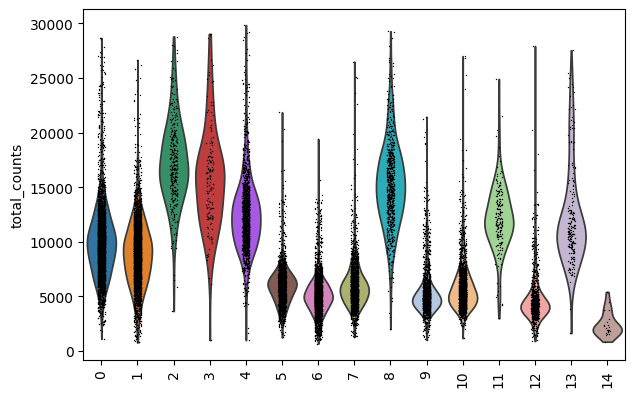

In [72]:
sample_2 = pipeline(adata_2)

### Cell Type Annotation Rationale (Sample 3)

CD8 T cells (Clusters 4,7): Express pan-T cell markers (CD3D, CD3E, CD3G) plus CD8-specific markers (CD8A, CD8B, KLRG1)

CD4 T cells (Clusters 0,1): Express pan-T cell markers (CD3D, CD3E, CD3G) with CD4 and GATA3 expression higher than CD8 cells

B cells (Cluster 6): High expression of B cell markers (CD19, CD79A, CD79B, MS4A1/CD20)

NK cells (Cluster 5): High GNLY and NKG7 expression without T cell markers

CD14 Monocytes (Cluster 2): Classical monocyte markers (CD14, LYZ, S100A8, S100A9, CCR2)

CD16 Monocytes (Cluster 3): High FCGR3A (CD16) expression with low CD14
    

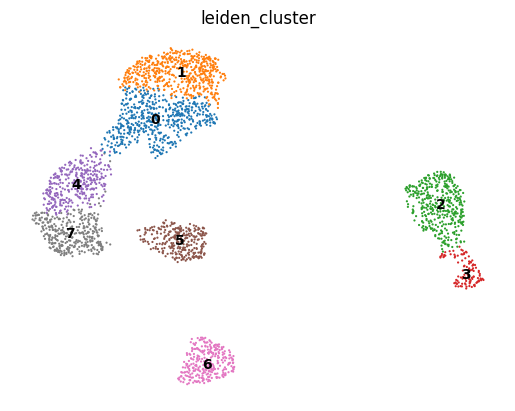

categories: 0, 1, 2, etc.
var_group_labels: CD14 Monocyte, CD14 CD16 Monocyte, CD16 Monocyte, etc.


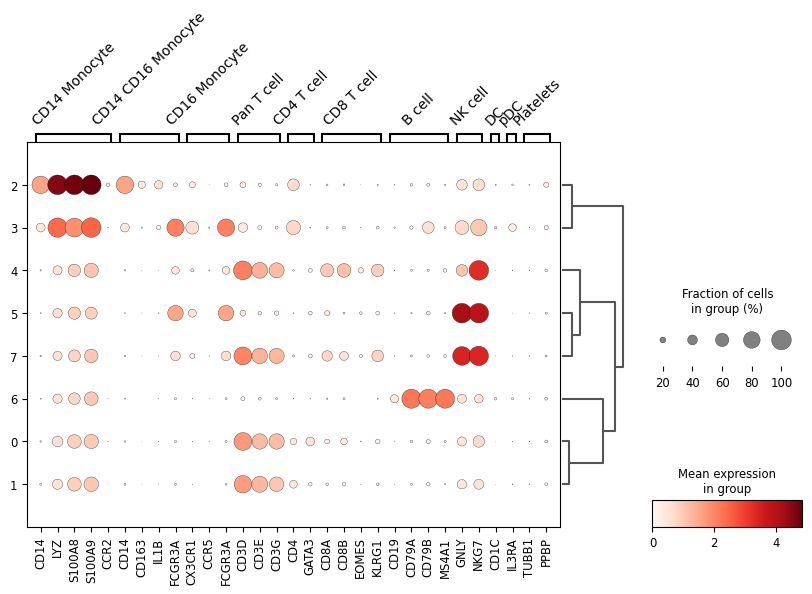

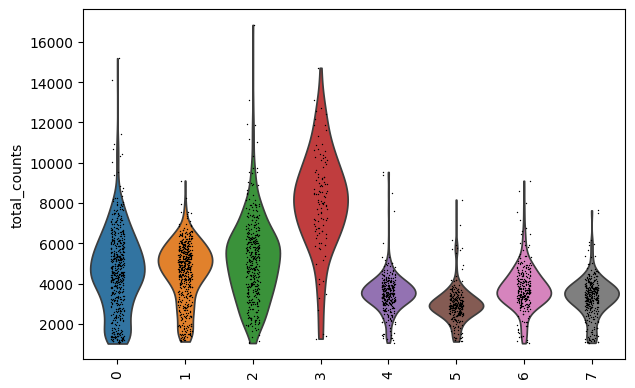

In [73]:
sample_3 = pipeline(adata_3)

In [13]:
my_sample_annotations = {
    'Sample_1': {'0': 'CD8 T cell',
                 '1':'CD4 T cell',
                 '2': 'Platelets',
                 '3': 'Mono/DC doublet',
                 '4':'CD14 Monocyte',
                 '5': 'CD14 Monocyte',
                 '6': 'NK cell',
                 '7': 'CD8 T cell',
                 '8': 'B cell',
                 '9': 'Pan T cell',
                 '10': 'pDC',
                 '11': 'CD16 Monocyte',
                 '12':'T/Mono doublet',
                 '13':'B cell',
                 '14': 'B/Mono doublet'},
    'Sample_2': {'0': 'CD14 Monocyte',
                 '1':'CD14 Monocyte',
                 '2': 'Mono/DC doublet',
                 '3': 'B/Mono doublet',
                 '4':'CD16 Monocyte',
                 '5': 'CD8 T cell',
                 '6': 'Pan T cell',
                 '7': 'CD4 T cell',
                 '8': 'T/Mono doublet',
                 '9': 'CD8 T cell',
                 '10': 'B cell',
                 '11': 'pDC',
                 '12':'NK cell',
                 '13':'B cell',
                 '14': 'Platelets'},
    'Sample_3': {'0': 'CD4 T cell',
                 '1':'CD4 T cell',
                 '2': 'CD14 Monocyte',
                 '3': 'CD16 Monocyte',
                 '4':'CD8 T cell',
                 '5': 'NK cell',
                 '6': 'B cell',
                 '7': 'CD8 T cell'}}

In [78]:
sample_adata= {'Sample_1': sample_1,'Sample_2': sample_2,'Sample_3': sample_3}

<a id='bar-2'></a>
## 2.2 Stacked bar of each sample compared to literature

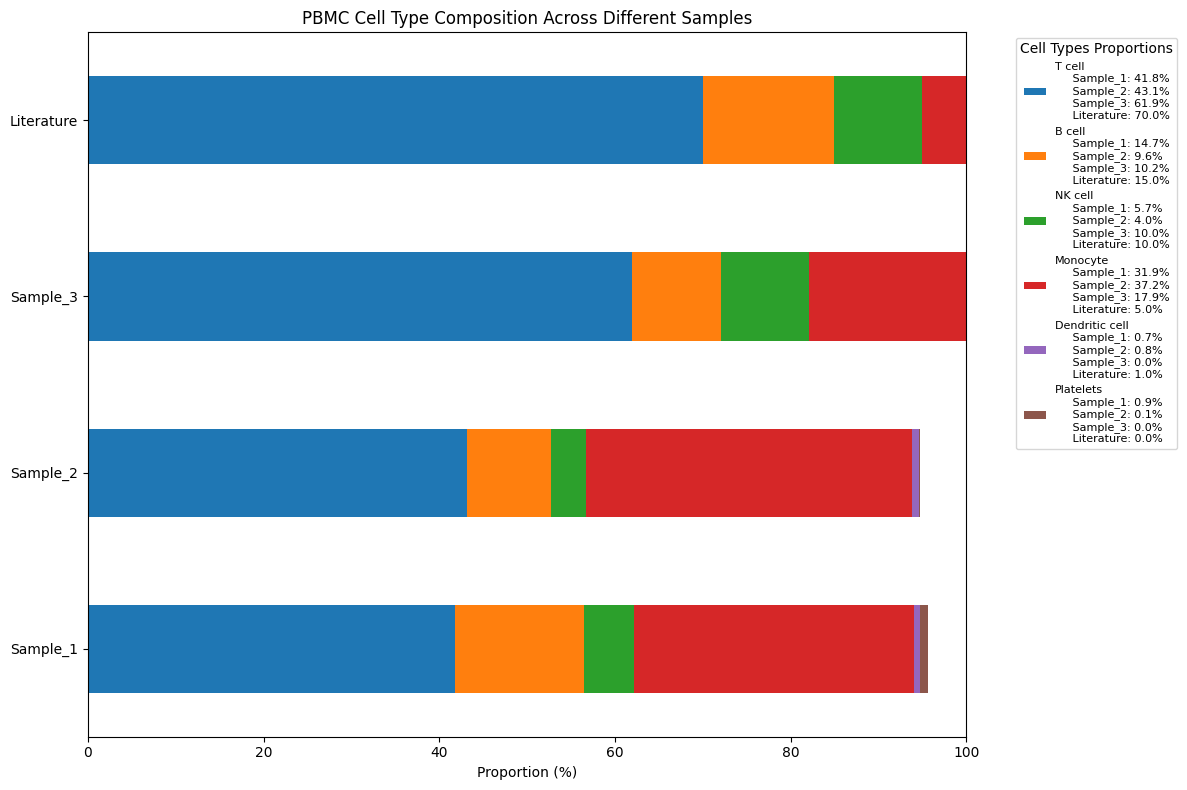

In [82]:
proportion_sample_results =stacked_bar(annotations_dict=my_sample_annotations, adata_dict=sample_adata,title='PBMC Cell Type Composition Across Different Samples')

In [87]:
proportion_sample_results

,T cell,B cell,NK cell,Monocyte,Dendritic cell,Platelets
Sample_1,41.76,14.71,5.67,31.90,0.74,0.89
Sample_2,43.12,9.58,4.01,37.16,0.79,0.10
Sample_3,61.92,10.20,9.99,17.89,0.00,0.00
Literature,70.00,15.00,10.00,5.00,1.00,0.00


<a id='summary-2'></a>
## 2.3 Do you think that the variation that you observe in the scRNAseq-based estimates primarily reflect real biological variation, or do they reflect technical variation due to the vicissitudes of scRNAseq data generation and analysis?

I believe that variation is predominantly technical (probably 80-85%) rather than biological. All three samples come from healthy donors and should therefore match literature values established by flow cytometry (monocytes: 10-30%, T cells: 45-70%). However, the samples show a clear gradient: Sample 3 with the highest sequencing depth (115,061  reads/cell) matches literature perfectly with 15.7% monocytes and 61.1% T cells. Sample 1 with medium depth (54,000 reads/cell) shows moderate deviation at 31.9% monocytes and 41.8% T cells. Sample 2 with the lowest depth (35,000 reads/cell) shows severe deviation at 37.2% monocytes and 41.1% T cells. The accuracy directly correlates with technical parameters: more sequencing depth equals closer to the correct answer, less depth equals more inaccurate measurements.

This pattern demonstrates technical artifacts rather than biological variation. If these were real biological differences between the three healthy donors, I would expect random scatter around the literature mean. Maybe one donor with high monocytes, another with low monocytes, in unpredictable patterns. Instead, all deviations go in the same systematic direction (monocyte enrichment, T cell depletion) and the magnitude of deviation perfectly tracks with sequencing depth. This occurs because scRNA-seq with shallow sequencing suffers from dropout of lowly expressed genes, which disproportionately affects small cells with less RNA content like T cells, while large metabolically active monocytes with more RNA are preferentially captured and counted. The platelet contamination in Samples 1 and 2 (but not 3) provides additional definitive proof of technical quality issues.

The variation reflects the technical limitations of scRNA-seq for quantitative compositional analysis rather than genuine biological heterogeneity. Literature values from flow cytometry represent the ground truth for healthy PBMC composition, and the scRNA-seq samples systematically deviate from this truth in proportion to their technical constraints. Sample 3's match to literature occurs because its exceptional sequencing depth (115,061 reads/cell) overcomes the inherent biases of droplet-based methods, not because that donor is biologically different. As Carangelo et al. emphasized, scRNA-seq is powerful for discovering cell types but requires carefully controlled experimental conditions to produce quantitatively accurate cell type proportions—exactly the issue demonstrated here. To reliably measure biological variation, all samples should be processed with identical chemistry, sequencing depth, and in the same batch. Otherwise, there are a lot of confounding variables that prevents us from directly comparing the samples.

Sources:

https://www.caltagmedsystems.co.uk/information/peripheral-blood-mononuclear-cells-a-brief-review/?geo_country=Canada

https://ucallmlabs.com/understanding-pbmc-cell-types-and-their-functions/


Carangelo, G., Magi, A., & Semeraro, R. (2022). From multitude to singularity: An up-to-date overview of scRNA-seq data generation and analysis. Frontiers in genetics, 13, 994069. https://doi.org/10.3389/fgene.2022.994069

https://histology.leeds.ac.uk/blood/blood_wbc.php

<a id='question-3'></a>
# 3. Impact of read depth, population size, and analysis pipeline steps/parameters on the power to detect rare populations

In [17]:
sample_1.obs['cell_type'] = sample_1.obs['leiden_cluster'].map(my_sample_annotations['Sample_1'])

In [68]:
cell_type_counts = sample_1.obs['cell_type'].value_counts()
print(cell_type_counts)
print(f'Total cells: {len(sample_1.obs['cell_type'])}')

target_cell_type = 'CD14 Monocyte'
original_count = cell_type_counts[target_cell_type]
print(f'\nOriginal {target_cell_type} count: {original_count}')

cell_type
CD14 Monocyte      3088
CD8 T cell         1636
B cell             1602
CD4 T cell         1500
Pan T cell         1413
NK cell             618
CD16 Monocyte       387
T/Mono doublet      244
Mono/DC doublet     157
Platelets            97
pDC                  81
B/Mono doublet       68
Name: count, dtype: int64
Total cells: 10891

Original CD14 Monocyte count: 3088


<a id='pipeline'></a>
## 3.1 Pipeline

The pipeline builds upon the PBMC dataset from Sample 1, which contains my annotated "CD14 Monocyte" population that serves as the target for these simulations.

**1. Simulating a Rare Population**

The first step in the pipeline is to artificially create a dataset where the cell type of interest is present at a defined, rare frequency. To achieve this, I wrote a function that takes the fully annotated sample_1 dataset and selectively subsamples the target cells.

Function `create_rare_population`:

- The function identifies all cells belonging to the target cell type (e.g., 'CD14 Monocyte') and all other ('background') cells.
- It calculates the exact number of target cells to retain in order to achieve a desired final fraction (0.1%, 1%, or 10% of the total population).  
- It then randomly selects this calculated number of rare cells and combines them with all of the other cells to create a new AnnData object. This creates a biologically realistic dataset where a genuine population is now rare, allowing us to test if the pipeline can still recover it.

**2. Simulating Reduced Sequencing Depth**

The second manipulation accounts for the fact that sequencing depth varies between experiments and samples. To model this, I used Scanpy's built-in downsampling function to simulate shallower sequencing.

Function `reduce_read_depth`:

- The function takes a full-depth dataset and downsamples the total UMI counts per cell to a user-specified target (50,000, 30,000, or 10,000 UMIs per cell).

**3. Systematic Testing of Pipeline Parameters**

Function `test_rare_detection`:

The core of the analysis involves running a modified version of the `pipeline()` function from Question 1 on all combinations of the simulated conditions. Instead of testing every possible parameter, I designed a targeted grid of parameter variations to understand their specific effects.

The pipeline tests the following conditions:

- Rare Population Sizes: 0.1%, 1%, and 10% of the total cell population.
- Read Depths: 50,000, 30,000, and 10,000 UMIs per cell.
- Pipeline Parameter Variations:
    - *Baseline:* The standard parameters established in Question 1 (10 PCs, 15 neighbors, 0.5 resolution).
    - *Resolution:* Testing the effect of cluster granularity by using a high resolution (1.0) and a low resolution (0.1).
    - *PCs:* Testing the effect of dimensionality reduction by using more PCs (30) and fewer PCs (5).
    - *Neighbors:* Testing the effect of the graph structure by using more neighbors (30) and fewer neighbors (5).

**4. Defining and Scoring "Detection"**

Function `check_rare_population`:

- It takes the pipeline results and maps the true identity of each cell (from the original, pre-downsampling annotation) onto the new clustering results. This allows us to see which Leiden cluster contains the rare cells.
- The function identifies the cluster that contains the highest number of the rare cells. It then calculates the purity, which is the percentage of all rare cells that fall into this single top cluster.
- A rare population is considered 'detected' if this purity exceeds 50%. This threshold ensures that the rare cells are not scattered randomly across many clusters but are concentrated together, forming a distinct, identifiable group.

In [ ]:
#create a dataset where your target cell type is rare
def create_rare_population(adata, rare_cell_type, target_fraction):
    adata_subset = adata.copy()

    #which cells are the rare type
    rare_cells = adata_subset.obs['cell_type'] == rare_cell_type
    other_cells = ~rare_cells

    rare_indices = np.where(rare_cells)[0]
    other_indices = np.where(other_cells)[0]

    #calculate how many rare cells to keep to reach target fraction
    #target_fraction = rare_count / (rare_count + other_count)
    n_other = len(other_indices)
    n_rare_keep = int((target_fraction*n_other) / (1-target_fraction))

    #randomly choose that many rare cells
    np.random.seed(0)
    keep_rare = np.random.choice(rare_indices, n_rare_keep, replace=False)

    #combine with all other cells
    keep_all = np.concatenate([keep_rare, other_indices])

    return adata_subset[keep_all].copy()


In [ ]:
#reduce sequencing depth (simulate less data)
def reduce_read_depth(adata, target_counts=5000):
    adata_down = adata.copy()
    sc.pp.downsample_counts(adata_down, total_counts=target_counts, random_state=0)
    return adata_down

In [ ]:
def check_rare_population(adata_result, adata_original, rare_cell_type):
    rare_cells = adata_original.obs['cell_type'] == rare_cell_type

    if rare_cells.sum() == 0:
        return False, 0

    #What clusters are they in?
    rare_clusters = adata_result.obs.loc[rare_cells, 'leiden_cluster']

    #Are most of them in one cluster?
    top_cluster = rare_clusters.value_counts().index[0]
    percent_in_top = rare_clusters.value_counts().iloc[0] / len(rare_clusters)

    #we consider it 'detected' if >50% are in one cluster
    detected = percent_in_top > 0.5

    return detected, percent_in_top

In [48]:
def test_rare_detection(adata_full, rare_type='CD14 Monocyte'):

    # What we'll test
    rare_fractions = [0.001, 0.01, 0.1]  # 0.1% to 10%
    read_depths = [50000, 30000, 10000]  # UMIs per cell
    #pipeline parameters to test
    param_tests = [
        {'name': 'Baseline', 'n_pcs': 10, 'n_neighbors': 15, 'resolution': 0.5},
        {'name': 'High resolution', 'n_pcs': 10, 'n_neighbors': 15, 'resolution': 1.0},
        {'name': 'Low resolution', 'n_pcs': 10, 'n_neighbors': 15, 'resolution': 0.1},
        {'name': 'More PCs', 'n_pcs': 30, 'n_neighbors': 15, 'resolution': 0.5},
        {'name': 'Fewer PCs', 'n_pcs': 5, 'n_neighbors': 15, 'resolution': 0.5},
        {'name': 'More neighbors', 'n_pcs': 10, 'n_neighbors': 30, 'resolution': 0.5},
        {'name': 'Fewer neighbors', 'n_pcs': 10, 'n_neighbors': 5, 'resolution': 0.5}]

    results = []

    #loop through all combinations
    for params in param_tests:
        print(f'\nTesting pipeline: {params['name']}')
        for fraction in rare_fractions:
            print(f'\n  Rare fraction: {fraction*100:.1f}%')
            #create dataset with this rare fraction
            adata_rare = create_rare_population(adata_full, rare_type, fraction)
            for depth in read_depths:
                print(f'    Read depth: {depth} UMIs', end=' ')

                #downsample reads
                if depth < 50000:
                    adata_down = reduce_read_depth(adata_rare, depth)
                else:
                    adata_down = adata_rare.copy()

                adata_result = pipeline(
                    adata_down,
                    silent=True,
                    filter_mt=False,
                    filter_counts=False,
                    filter_genes=False,
                    normalize=True,
                    n_pcs=params['n_pcs'],
                    n_neighbors=params['n_neighbors'],
                    leiden_resolution=params['resolution'])

                #check if we found the rare cells
                detected, purity = check_rare_population(adata_result, adata_rare, rare_type)

                results.append({
                    'pipeline': params['name'],
                    'n_pcs': params['n_pcs'],
                    'n_neighbors': params['n_neighbors'],
                    'resolution': params['resolution'],
                    'fraction': fraction,
                    'depth': depth,
                    'detected': detected,
                    'purity': purity,
                    'total_cells': len(adata_result)})

                print(f'- Detected: {detected} (Purity: {purity:.2f})')
    results_df = pd.DataFrame(results)

    return results_df

In [50]:
results = test_rare_detection(sample_1, rare_type='CD14 Monocyte')


Testing pipeline: Baseline

  Rare fraction: 0.1%
    Read depth: 50000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: True (Purity: 1.00)
    Read depth: 30000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: False (Purity: 0.29)
    Read depth: 10000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: True (Purity: 0.71)

  Rare fraction: 1.0%
    Read depth: 50000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: True (Purity: 1.00)
    Read depth: 30000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: False (Purity: 0.14)
    Read depth: 10000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: True (Purity: 0.51)

  Rare fraction: 10.0%
    Read depth: 50000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: True (Purity: 0.97)
    Read depth: 30000 UMIs WARNING: adata.X seems to be already log-transformed.
- Detected: False (Purity: 0

<a id='Plots'></a>
## 3.2 Plots

Heatmap of Detection Rate by Read Depth and Population Size

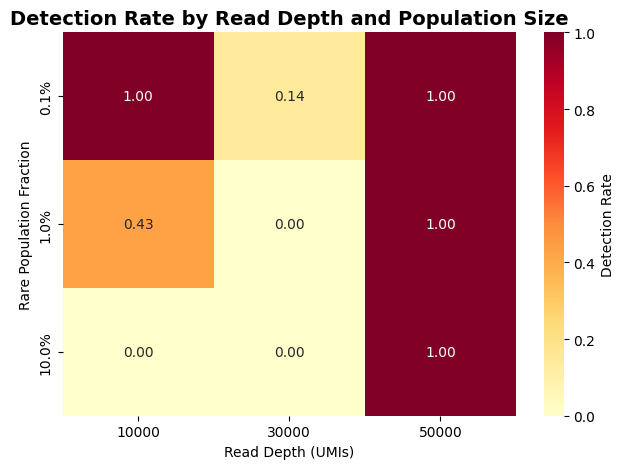

In [60]:
#mean detection rate
pivot_overall = results.pivot_table(values='detected', index='fraction', columns='depth', aggfunc='mean')

sns.heatmap(pivot_overall, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Detection Rate'}, vmin=0, vmax=1)

plt.title('Detection Rate by Read Depth and Population Size', fontsize=14, fontweight='bold')
plt.xlabel('Read Depth (UMIs)')
plt.ylabel('Rare Population Fraction')
y_labels = [f'{float(idx)*100:.1f}%' for idx in pivot_overall.index]
plt.gca().set_yticklabels(y_labels)
plt.tight_layout()
plt.show()

### Heatmap grid of each pipeline

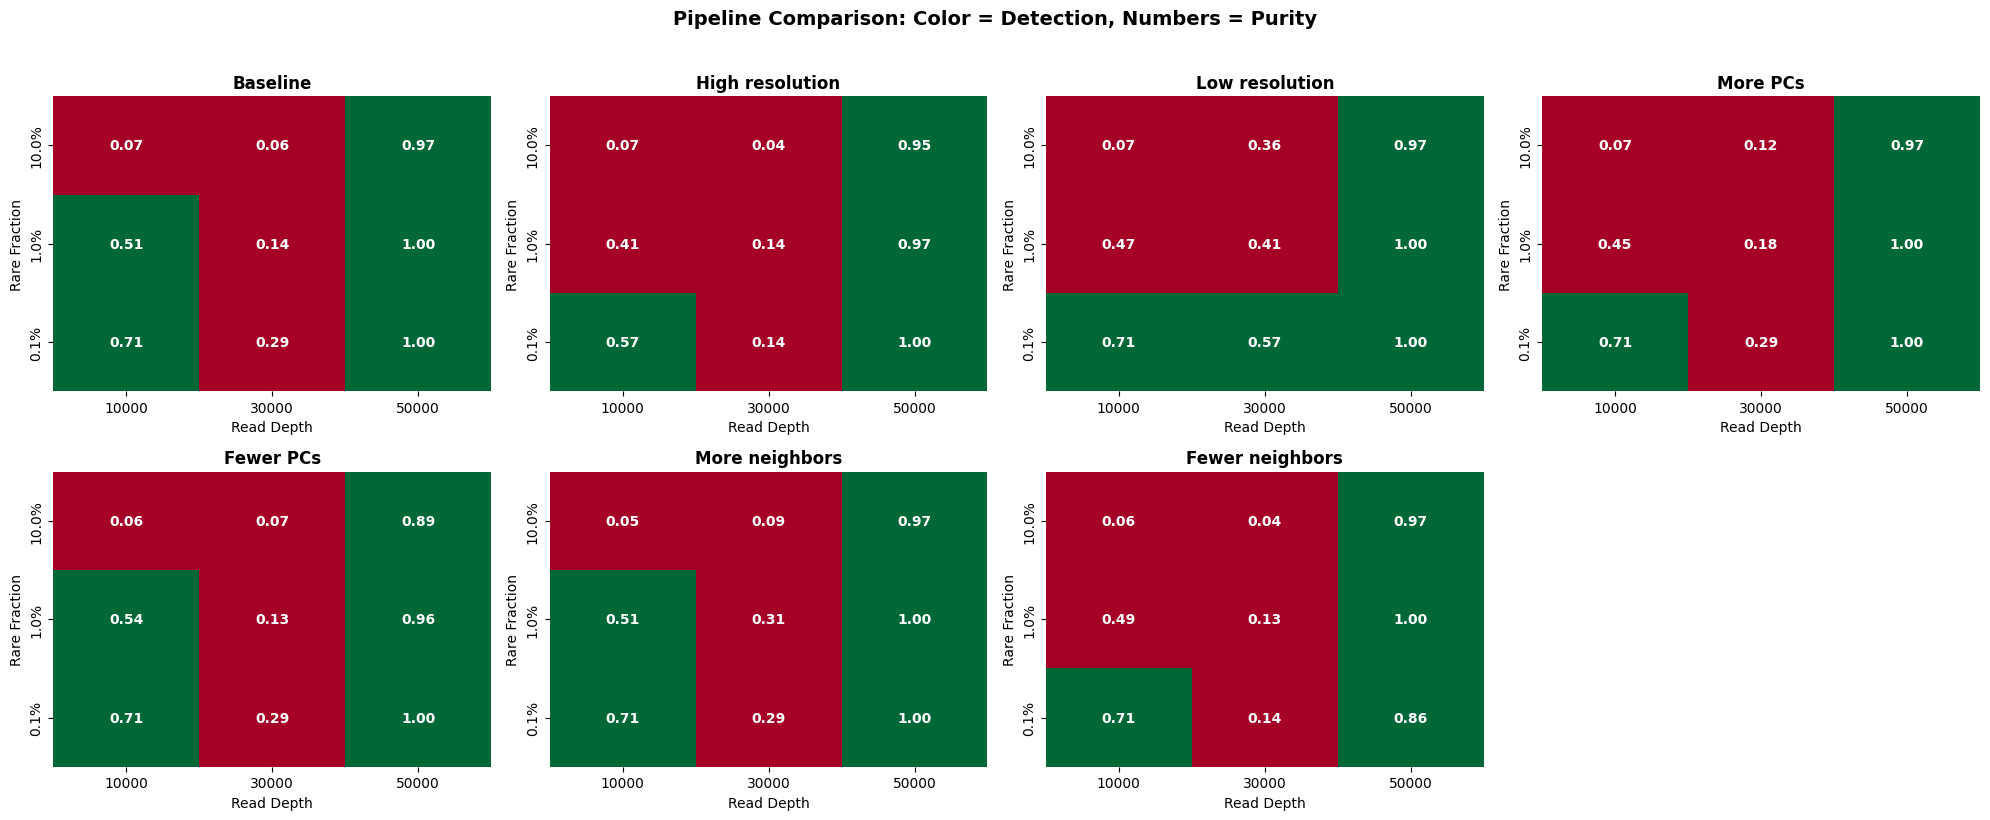

In [75]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for idx, pipeline in enumerate(df['Pipeline'].unique()):
    ax = axes[idx]
    pipe_data = df[df['Pipeline'] == pipeline]

    detect_pivot = pipe_data.pivot_table(values='Detected', index='Fraction', columns='Depth', aggfunc='mean')
    purity_pivot = pipe_data.pivot_table(values='Purity', index='Fraction', columns='Depth', aggfunc='mean')

    detect_pivot = detect_pivot.sort_index(ascending=False)
    purity_pivot = purity_pivot.sort_index(ascending=False)

    #detection as color
    sns.heatmap(detect_pivot,
                annot=purity_pivot,  #purity as annotation
                fmt='.2f',
                cmap='RdYlGn',
                vmin=0, vmax=1,
                cbar=False,
                ax=ax,
                annot_kws={'size': 10, 'fontweight': 'bold'})

    y_labels = [f'{float(i)*100:.1f}%' for i in detect_pivot.index]
    ax.set_yticklabels(y_labels)

    ax.set_title(pipeline, fontsize=12, fontweight='bold')
    ax.set_xlabel('Read Depth')
    ax.set_ylabel('Rare Fraction')
axes[7].set_visible(False)

plt.suptitle('Pipeline Comparison: Color = Detection, Numbers = Purity',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Pipeline Performance Comparison

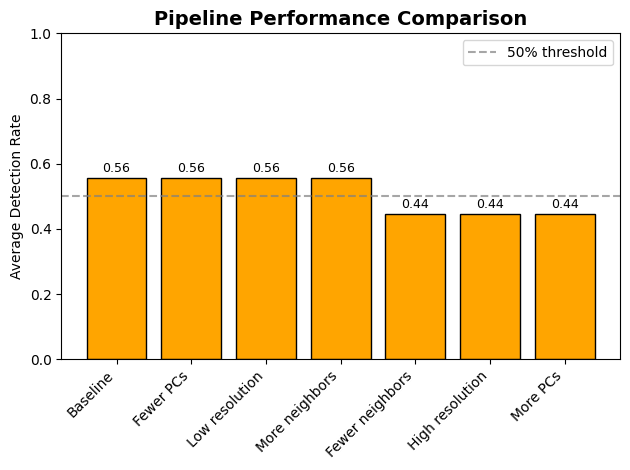

In [53]:
pipeline_detection = results.groupby('pipeline')['detected'].mean().sort_values(ascending=False)

#color bars by performance
colors = ['darkgreen' if x > 0.7 else 'orange' if x > 0.4 else 'red'
          for x in pipeline_detection.values]

bars = plt.bar(range(len(pipeline_detection)), pipeline_detection.values,
               color=colors, edgecolor='black')

plt.ylabel('Average Detection Rate')
plt.title('Pipeline Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(range(len(pipeline_detection)), pipeline_detection.index, rotation=45, ha='right')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50% threshold')
plt.legend()
plt.ylim(0, 1)

for i, v in enumerate(pipeline_detection.values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Pipeline Performance for Rare Populations (<2%)

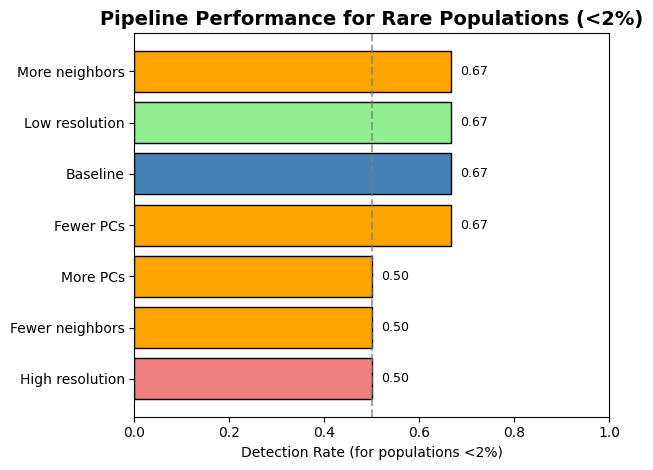

In [63]:
challenging = results[results['fraction'] < 0.02]

#group by pipeline and calculate mean detection
param_effects = challenging.groupby('pipeline')['detected'].mean().sort_values()

y_pos = np.arange(len(param_effects))
colors2 = ['steelblue' if 'Baseline' in x else 'lightcoral' if 'High' in x else
           'lightgreen' if 'Low' in x else 'orange' for x in param_effects.index]
plt.barh(y_pos, param_effects.values, color=colors2, edgecolor='black')
plt.yticks(y_pos, param_effects.index)
plt.xlabel('Detection Rate (for populations <2%)')
plt.title('Pipeline Performance for Rare Populations (<2%)', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
plt.xlim(0, 1)

for i, v in enumerate(param_effects.values):
    plt.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Summary metrics per pipeline

In [66]:
summary = []
for pipeline in results['pipeline'].unique():
    pipe_data = results[results['pipeline'] == pipeline]

    overall_detection = pipe_data['detected'].mean()

    #detection at hardest condition (smallest fraction, lowest depth)
    hard_condition = pipe_data[(pipe_data['fraction'] == 0.001) &
                               (pipe_data['depth'] == 10000)]['detected'].values
    hard_detection = hard_condition[0] if len(hard_condition) > 0 else None

    #average purity when detected
    avg_purity = pipe_data[pipe_data['detected']]['purity'].mean()

    summary.append({
        'Pipeline': pipeline,
        'Overall Detection': f'{overall_detection:.1%}',
        'Detection (0.1%, 10k)': f'{hard_detection}' if hard_detection is not None else 'N/A',
        'Avg Purity': f'{avg_purity:.2f}'})

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

       Pipeline Overall Detection Detection (0.1%, 10k) Avg Purity
       Baseline             55.6%                  True       0.84
High resolution             44.4%                  True       0.87
 Low resolution             55.6%                  True       0.85
       More PCs             44.4%                  True       0.92
      Fewer PCs             55.6%                  True       0.82
 More neighbors             55.6%                  True       0.84
Fewer neighbors             44.4%                  True       0.89


<a id='Report'></a>
## 3.3 Report

**Cell Type Selection:**

CD14 Monocytes were selected as the 'rare' population for this analysi. The original count: 3,088 cells from 10,891 total cells. This cell type represents an ideal candidate because:
- Monocytes have a distinct transcriptional profile from other immune cell types and dominated the PC1.
- The population is sufficiently large to subsample at various fractions (0.1%, 1%, 10%). 0.1% of the cells is 3 cells.


**Detection Success Rate by Condition**

Read Depth = 50,000 UMIs
- 0.1% rare fraction: 7/7 pipelines detected (100%)
- 1.0% rare fraction: 7/7 pipelines detected (100%)
- 10.0% rare fraction: 7/7 pipelines detected (100%)
- All tested fractions (0.1%, 1%, 10%) were reliably detected
- The actual limit may be even lower than 0.1% but was not tested

Read Depth = 30,000 UMIs
- 0.1% rare fraction: 1/7 pipelines detected (14.2%)
- 1.0% rare fraction: 0/7 pipelines detected (0%)
- 10.0% rare fraction: 0/7 pipelines detected (0%)
- Only 1/21 conditions successfully detected (0.1% with Low resolution pipeline, purity 0.57)

Read Depth = 10,000 UMIs
- 0.1% rare fraction: 7/7 pipelines detected (100%)
- 1.0% rare fraction: 3/7 pipelines detected (42.9%)
- 10.0% rare fraction: 0/8 pipelines detected (0%)

**Purity Analysis**
When clusters were detected, purity varied considerably:

- High purity ($>$0.90): Primarily at 50,000 UMIs across all rare fractions
- Medium purity (0.50-0.90): Mixed conditions, often at 10,000 UMIs with 0.1% fraction (0.71 purity)
- Low purity ($<$ 0.50): Common at 30,000 UMIs and with larger rare fractions at lower depths

We see that read depth is the dominant factor determining detection success.The results show a striking pattern:

- 50,000 UMIs: Near-perfect detection (100% across all rare fractions and pipelines)
- 30,000 UMIs: Detection failure (failure rate across conditions)
- 10,000 UMIs: Intermediate performance, highly dependent on rare fraction size

This creates a non-linear relationship where 30,000 UMIs represents a critical failure zone for this dataset, while both higher and lower depths show better performance (though with different purity profiles).

** Population Size Shows Inverse Relationship at Low Read Depths**

Counterintuitively, smaller rare fractions (0.1%) were more detectable than larger fractions (10%) at 10,000 UMIs. At 10,000 UMIs: 0.1% detected in 7/7 pipelines vs 10% detected in 0/7 pipelines. This likely reflects signal dilution: with fewer UMIs per cell, a larger rare population may fragment into multiple weak clusters that fail to separate cleanly. At 50,000 UMIs, this effect disappears as sufficient resolution exists for all fractions

**Pipeline Parameters Have Minimal Impact**

Across the 7 different pipeline configurations tested:
- Resolution settings (high vs low): No substantial difference in detection
- Number of PCs (more vs fewer): Minimal impact on detection success
- Neighbor count (more vs fewer): Minor effects, with "Fewer neighbors" showing slightly reduced purity at 50,000 UMIs (0.86 vs 1.00 for 0.1% fraction). This might be due to the overfragmentation.

The consistency across pipelines suggests that when data quality is sufficient, the analysis method is relatively robust. However, no pipeline parameter could rescue poor detection at 30,000 UMIs.

**Interpretation and Mechanisms**

Why Does 30,000 UMIs Fail?

There might be insufficient resolution to capture monocyte-specific marker gene, and at this depth, technical noise may overwhelm the biological signal differentiating monocytes. At 30,000 UMIs, background cells have might just enough counts to register in the log space but not enough to be clearly separated.

Why Does 10,000 UMIs Work for Small Fractions?

The better performance of 10,000 UMIs for the 0.1% fraction compared to larger fractions suggests that with severe downsampling, only the most transcriptionally distinct cells may be retained. A very small, highly distinct population may form a tight cluster, while a larger population at low depth fragments into multiple weak subclusters. The fact that 10,000 UMIs works for small fractions (0.1%) but fails for large fractions (10%) is entirely driven by my choice of monocytes as the rare population. I also chose a cell type that have high loadings in PC1. This result would likely not replicate with a more subtle cell type like adult stem cells as they usually have low abundance genes they they might share with their linage. 

**Conclusion**

This analysis reveals that read depth is overwhelmingly the most important factor for detecting rare cell populations in scRNA-seq data. The relationship is non-linear, with a critical failure zone around 30,000 UMIs and robust detection at $\geq$50,000 UMIs for populations as small as 0.1% of total cells. Pipeline parameters (resolution, PCs, neighbors) show minimal impact relative to data quality. Though, the ones that did work the best were the methods that over-fragment the dataset. The counterintuitive finding that smaller rare fractions are sometimes more detectable than larger ones at low read depths highlights the complex interplay between sequencing depth and population size.

While this analysis provides insights into the factors affecting rare cell detection, it is important to acknowledge that these findings are based on a single cell type, the CD14+ monocytes, within a PBMC dataset. Monocytes possess an unusually strong transcriptional signature dominated by highly abundant, exclusive markers (like CD14, LYZ, S100A8/A9) that make them exceptionally detectable even under challenging conditions. This likely explains the counterintuitive success at 10,000 UMIs for 0.1% fractions: a few super expressed monocytes retained CD14 while other monocytes dropped out, artificially inflating purity for the survivors. 

Future tests should validate these findings using cell types with more subtle transcriptional profiles, such as Pan T cells or dendritic cells. Ideally, this would include adult stem cells, whose detection depends on low-abundance, combinatorial signatures shared with their progeny, which is a scenario where depth requirements are expected to be substantially higher. However, the PBMC dataset used here contains insufficient numbers of such cell types for me to subsample at rare fractions (only 3 for monocytes at 0.1%).